## Выпускная квалификационная работа САБДИС-802 

### Вариант 4. Open Credit Card

__Аналитическая задача__: Провести анализ данных с целью выявления характеристик клиентов, которые открывают и не открывают кредитную карту.

In [118]:
import warnings

warnings.filterwarnings("ignore")

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
data = pd.read_csv("vkr_dataset_open_credit_card.csv", sep=",")
data

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,score_shk,education,tariff_id,living_region,okrug,avregzarplata,monthly_income,credit_count,overdue_credit_count,open_account_flg,date_bank
0,1,2,48.0000,3.0000,15,59998,10,"0,770249",2.0000,28,23.0000,8.0000,"25,850.0000","30,000.0000",1.0000,1.0000,0,2016-02-16 18:54:34
1,2,1,28.0000,NaN,15,10889,6,"0,248514",2.0000,2,30.0000,7.0000,"66,880.0000","43,000.0000",2.0000,0.0000,0,2016-02-15 12:39:04
2,3,2,32.0000,3.0000,14,10728,12,"0,459589",4.0000,2,64.0000,2.0000,"23,430.0000","23,000.0000",5.0000,0.0000,0,2015-01-27 18:57:19
3,4,1,27.0000,2.0000,14,"12009,09",12,"0,362536",2.0000,2,8.0000,8.0000,"23,650.0000","17,000.0000",2.0000,0.0000,0,2019-05-02 17:57:10
4,5,2,45.0000,3.0000,14,"16908,89",10,"0,421385",4.0000,2,77.0000,6.0000,"26,620.0000",NaN,1.0000,0.0000,0,2015-09-22 16:28:33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170741,170742,1,27.0000,4.0000,14,64867,12,"0,535257",2.0000,2,57.0000,2.0000,"27,060.0000","40,000.0000",6.0000,0.0000,0,2018-11-24 18:35:26
170742,170743,1,24.0000,3.0000,14,17640,6,"0,573287",4.0000,28,63.0000,3.0000,"45,430.0000","30,000.0000",1.0000,0.0000,0,2018-06-08 16:06:39
170743,170744,1,31.0000,4.0000,14,"27556,47",10,"0,416098",2.0000,19,41.0000,1.0000,"33,990.0000","40,000.0000",1.0000,0.0000,0,2016-09-24 12:18:06
170744,170745,1,53.0000,2.0000,10,6189,12,"0,482595",4.0000,2,39.0000,2.0000,"22,990.0000","31,000.0000",2.0000,0.0000,0,2017-11-05 18:57:58


##### Описание данных
<small>За исключением признака `client_id`</small>

|Признак|Комментарий| Тип переменной | 
|--:|:--| :-- |
|`gender`|Пол| Категориальная, номинальная |
|`age`| Возраст | Количественная, непрерывная | 
|`marital_status`|Семейный статус| Категориальная, номинальная |
|`job_position`|Работа| Категориальная, номинальная |
|`credit_sum`|Сумма кредита| Количественная, непрерывная |
|`credit_month`|Срок кредитования| Количественная, дискретная |
|`score_shk`|Внутренняя скоринговая оценка| Количественная, непрерывная |
|`education`|Образование| Категориальная, номинальная |
|`tariff_id`|Идентификационный номер тарифа| Категориальная, номинальная |
|`living_region`|Регион| Категориальная, номинальная |
|`monthly_income`|Месячный заработок| Количественная, непрерывная |
|`credit_count`|Количество кредитов у клиента| Количественная, дискретная |
|`overdue_credit_count`|Количество просроченных кредитов у клиента | Количественная, дискретная |
|`open_account_flg`|Факт открытия кредитного счета в данном банке| Категориальная, бинарная |
|`avregzarplata`| Средняя заработная плата в регионе | Количественная, непрерывная |
|`okrug`|Федеральный округ| Категориальная, номинальная |
|`date_bank`|Дата обращения в банк| Временная |


##### Исследование данных и их структуры

In [121]:
data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170746 entries, 0 to 170745
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   client_id             170746 non-null  int64  
 1   gender                170746 non-null  int64  
 2   age                   170744 non-null  float64
 3   marital_status        170741 non-null  float64
 4   job_position          170746 non-null  int64  
 5   credit_sum            170745 non-null  object 
 6   credit_month          170746 non-null  int64  
 7   score_shk             170743 non-null  object 
 8   education             170743 non-null  float64
 9   tariff_id             170746 non-null  int64  
 10  living_region         170554 non-null  float64
 11  okrug                 170554 non-null  float64
 12  avregzarplata         170554 non-null  float64
 13  monthly_income        170744 non-null  float64
 14  credit_count          161516 non-null  float64
 15  

In [122]:
from rich import print
from rich.table import Table

cols = data.columns.to_list()

table = Table(title="Оценка количества пустых значений",)
table.add_column("Признак", style="cyan")
table.add_column("Количество", style="magenta" )
table.add_column("Процент", justify="right", style="magenta")

for col in cols:
    null_sum = data[col].isna().sum()
    null_percent = data[col].isna().mean() * 100
    table.add_row(col, str(null_sum), f"{null_percent:.4f}")


print(table)

       Оценка количества пустых значений       
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Признак              ┃ Количество ┃ Процент ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ client_id            │ 0          │  0.0000 │
│ gender               │ 0          │  0.0000 │
│ age                  │ 2          │  0.0012 │
│ marital_status       │ 5          │  0.0029 │
│ job_position         │ 0          │  0.0000 │
│ credit_sum           │ 1          │  0.0006 │
│ credit_month         │ 0          │  0.0000 │
│ score_shk            │ 3          │  0.0018 │
│ education            │ 3          │  0.0018 │
│ tariff_id            │ 0          │  0.0000 │
│ living_region        │ 192        │  0.1124 │
│ okrug                │ 192        │  0.1124 │
│ avregzarplata        │ 192        │  0.1124 │
│ monthly_income       │ 2          │  0.0012 │
│ credit_count         │ 9230       │  5.4057 │
│ overdue_credit_count │ 9230       │  5.4057 │
│ open_account_flg     │ 0          │  0.0000 │
│ date_bank            │ 0          │  0.0000 │
└──────────────────────┴────────────┴─────────┘

##### Анализ пустых значений и стратегии замены
- У большинства признаков количество пропусков некритично (от 1 до 5) - такие записи можно удалить. 
- Подозрение вызывают:
    1) Одновременно 192 пропуска у `living_region`, `district` и `avg_income`. Между ними есть логическая связь: зная `living_region`, можно восстановить оставшиеся два признака. Аналогично с `avg_income` (предполагаем, что средняя зарплата по всем регионам разная). Параметр `district` менее информативен. 
    2) 9230 пропуска ($\approx$ 5.4%) у `credit_count` и `overdue_credit_count` - _одни из самых важных признаков_. 

In [123]:
# Считаем дубликаты
print("Количество дубликатов в датасете: ", data.duplicated().sum())

Количество дубликатов в датасете:  0

In [124]:
# Переименование заголовков
data.rename(
    {"avregzarplata": "avg_income", "okrug": "district"},
    axis=1,
    inplace=True,
)

In [125]:
# Преобразование типов данных
data["score_shk"] = data["score_shk"].str.replace(",", ".")
data["credit_sum"] = data["credit_sum"].str.replace(",", ".")

# object -> numeric
convert_to_numeric = ["score_shk", "credit_sum"]
data[convert_to_numeric] = data[convert_to_numeric].apply(
    pd.to_numeric, errors="coerce"
)

In [126]:
# Изменение формата даты - тип данных не меняется
data["date_bank"] = pd.to_datetime(data["date_bank"]).dt.strftime("%Y-%m-%d")

# object -> datetime
data["date_bank"] = pd.to_datetime(data["date_bank"])

In [127]:
print(
    "Даты обращения в банк:\n"
    f"Самая ранняя: {data.date_bank.min().date()}\n"
    f"Самая поздняя : {data.date_bank.max().date()}"
)

Даты обращения в банк:
Самая ранняя: 2015-01-01
Самая поздняя : 2021-12-31

#### Обнаружение аномалий

In [ ]:
from rich.console import Console
from rich.table import Table

# Категориальные признаки
categorical_cols = [
    "gender",
    "marital_status",
    "job_position",
    "education",
    "tariff_id",
    "living_region",
    "district",
    "open_account_flg"
]

console = Console()
table = Table()
table.add_column("Признак", style="cyan", no_wrap=True)
table.add_column("Число уникальных значений", style="magenta")

series = data[categorical_cols].nunique()

for feature, counts in series.items():
    table.add_row(str(feature), str(counts))

console.print(table)

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Признак          ┃ Число уникальных значений ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gender           │ 2                         │
│ marital_status   │ 5                         │
│ job_position     │ 18                        │
│ education        │ 5                         │
│ tariff_id        │ 33                        │
│ living_region    │ 81                        │
│ district         │ 8                         │
│ open_account_flg │ 2                         │
└──────────────────┴───────────────────────────┘

In [129]:
from rich import print
from rich.columns import Columns
from rich.table import Table

# Выведем распределения у признаков с малым количеством уникальных значений

console = Console()

console.print(
    "Распределение значений в категориальных признаках",
    style="bold",
    justify="center",
)

tables = []

for col in ["gender", "open_account_flg", "marital_status", "education", "district", "job_position"]:
    table = Table(title=f"{col}", title_style="bold green")

    table.add_column("Категория", style="cyan", no_wrap=True)
    table.add_column("Количество", style="cyan")
    table.add_column("Процент", justify="right", style="magenta")

    counts = data[col].value_counts()
    percent = data[col].value_counts(normalize=True) * 100
    
    for item, count in counts.items():
        pct = percent[item]
        table.add_row(str(item), str(count), f"{pct:.4f}%")
    
    tables.append(table)

print(Columns(tables, equal=True, expand=True))

                                 Распределение значений в категориальных признаках                                 

               gender                            open_account_flg                        marital_status            
┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓  ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓  ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Категория ┃ Количество ┃  Процент ┃  ┃ Категория ┃ Количество ┃  Процент ┃  ┃ Категория ┃ Количество ┃  Процент ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩  ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩  ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 1         │ 88697      │ 51.9468% │  │ 0         │ 140690     │ 82.3972% │  │ 3.0       │ 93952      │ 55.0260% │
│ 2         │ 82049      │ 48.0532% │  │ 1         │ 30056      │ 17.6028% │  │ 4.0       │ 52148      │ 30.5422% │
└───────────┴────────────┴──────────┘  └───────────┴────────────┴──────────┘  │ 2.0       │ 16970      │  9.9390% │
                                                                              │ 1.0       │ 4196       │  2.4575% │
                                                                              │ 5.0       │ 3475       │  2.0352% │
                                                                              └───────────┴────────────┴──────────┘
              education                              district                             job_position             
┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓  ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓  ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Категория ┃ Количество ┃  Процент ┃  ┃ Категория ┃ Количество ┃  Процент ┃  ┃ Категория ┃ Количество ┃  Процент ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩  ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩  ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 4.0       │ 87537      │ 51.2683% │  │ 7.0       │ 39049      │ 22.8954% │  │ 14        │ 134680     │ 78.8774% │
│ 2.0       │ 72593      │ 42.5159% │  │ 2.0       │ 36092      │ 21.1616% │  │ 15        │ 17674      │ 10.3510% │
│ 5.0       │ 9941       │  5.8222% │  │ 6.0       │ 22552      │ 13.2228% │  │ 2         │ 5591       │  3.2745% │
│ 3.0       │ 565        │  0.3309% │  │ 3.0       │ 22303      │ 13.0768% │  │ 10        │ 4107       │  2.4053% │
│ 1.0       │ 107        │  0.0627% │  │ 5.0       │ 18602      │ 10.9068% │  │ 4         │ 3750       │  2.1962% │
└───────────┴────────────┴──────────┘  │ 8.0       │ 18554      │ 10.8787% │  │ 1         │ 2791       │  1.6346% │
                                       │ 1.0       │ 7074       │  4.1477% │  │ 17        │ 656        │  0.3842% │
                                       │ 4.0       │ 6328       │  3.7103% │  │ 8         │ 537        │  0.3145% │
                                       └───────────┴────────────┴──────────┘  │ 16        │ 352        │  0.2062% │
                                                                              │ 6         │ 241        │  0.1411% │
                                                                              │ 3         │ 126        │  0.0738% │
                                                                              │ 18        │ 110        │  0.0644% │
                                                                              │ 11        │ 65         │  0.0381% │
                                                                              │ 13        │ 40         │  0.0234% │
                                                                              │ 12        │ 12         │  0.0070% │
                                                                              │ 5         │ 8          │  0.0047% │
                                                                              │ 7         │ 5          │  0.0029% │
                                                                              │ 9         │ 1          │  0.0006% │
                                                                              └───────────┴────────────┴──────────┘

##### Анализ распределений
* `gender`: Практически равномерное распределение.
* `open_account_flg`: Наблюдается дисбаланс классов: в выборке преобладают клиенты, которые не открыли кредитную карту (82.4%).
* `marital_status`: Около 85% клиентов занимают 3-я и 4-я категории. Если предположить, что в банковской кодировке значение `3` соответствует статусу "_Состоит в браке_", то такое распределение в целом согласуется с актуальной статистикой.
* `education`: Большая часть наблюдений относится к категориям 4 и 2 — 51.3% и 42.5% соответственно. Если предположить, что кодировки соответствуют высшему и среднему уровням образования, то здесь также наблюдается согласование с актуальной статистикой.
* `district`: Если считать, что кодировка банка совпадает с кодами федеральных округов, то здесь интересно сравнить с <a href='https://statprivat.ru/demo2020?r=6'>распределением численности населения по федеральным округам</a>:

    | Федеральный округ | Банк | Россия | 
    | --: | :-- | :-- |
    | 1 — Центральный | 7 | 1 |
    | 2 — Северо-Западный | 2 | 5 |
    | 3 — Южный | 4 | 4 |
    | 4 — Северо-Кавказский | 8 | 7 |
    | 5 — Приволжский | 5 | 2 |
    | 6 — Уральский | 3 | 6 |
    | 7 — Сибирский | 1 | 3 |
    | 8  — Дальневосточный | 6 | 8 |

    Распределение клиентов банка по ФО отличается от распределения населения по стране. В выборке банка наиболее представлены жители Сибирского, Северо-Западного, Уральского и Южных ФО, в то время как наиболее населенные Центральный и Приволжский ФО находятся ниже.
* `job_position`: Высокая концентрация в `14` (78.9%) и `15` (10.4%) категориях. Остальные представлены значительно реже. Без расшифровки кодов невозможно определить, являются ли ультра-редкие значения (напр., категории 9, 7 и 5 с менее чем 10 клиентами) аномальными.


In [130]:
tariff_counts = data.tariff_id.value_counts()
tariff_percents = data.tariff_id.value_counts(normalize=True) * 100

data1 = tariff_counts.iloc[:17]
data2 = tariff_counts.iloc[17:]


table1 = Table(title="tariff_id, часть 1", title_style="bold green")
table1.add_column("Категория", style="cyan", no_wrap=True)
table1.add_column("Количество", style="cyan")
table1.add_column("Процент", justify="right", style="magenta")

for item, count in data1.items():
    pct = tariff_percents[item]
    table1.add_row(str(item), str(count), f"{pct:.4f}%")

table2 = Table(title="tariff_id, часть 2", title_style="bold green")
table2.add_column("Категория", style="cyan", no_wrap=True)
table2.add_column("Количество", style="cyan")
table2.add_column("Процент", justify="right", style="magenta")

for item, count in data2.items():
    pct = tariff_percents[item]
    table2.add_row(str(item), str(count), f"{pct:.4f}%")

print(Columns([table1, table2]))

         tariff_id, часть 1                    tariff_id, часть 2         
┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓ ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Категория ┃ Количество ┃  Процент ┃ ┃ Категория ┃ Количество ┃ Процент ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩ ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ 2         │ 69355      │ 40.6188% │ │ 32        │ 414        │ 0.2425% │
│ 28        │ 39117      │ 22.9095% │ │ 10        │ 376        │ 0.2202% │
│ 19        │ 15537      │  9.0995% │ │ 11        │ 370        │ 0.2167% │
│ 20        │ 10970      │  6.4247% │ │ 31        │ 317        │ 0.1857% │
│ 25        │ 7497       │  4.3907% │ │ 12        │ 303        │ 0.1775% │
│ 30        │ 5538       │  3.2434% │ │ 21        │ 132        │ 0.0773% │
│ 22        │ 3930       │  2.3017% │ │ 13        │ 56         │ 0.0328% │
│ 18        │ 3339       │  1.9555% │ │ 5         │ 36         │ 0.0211% │
│ 3         │ 3232       │  1.8929% │ │ 14        │ 11         │ 0.0064% │
│ 1         │ 2245       │  1.3148% │ │ 16        │ 10         │ 0.0059% │
│ 23        │ 2228       │  1.3049% │ │ 26        │ 7          │ 0.0041% │
│ 6         │ 2102       │  1.2311% │ │ 15        │ 6          │ 0.0035% │
│ 29        │ 1007       │  0.5898% │ │ 24        │ 5          │ 0.0029% │
│ 8         │ 766        │  0.4486% │ │ 27        │ 2          │ 0.0012% │
│ 4         │ 717        │  0.4199% │ │ 33        │ 1          │ 0.0006% │
│ 9         │ 579        │  0.3391% │ │ 17        │ 1          │ 0.0006% │
│ 7         │ 540        │  0.3163% │ └───────────┴────────────┴─────────┘
└───────────┴────────────┴──────────┘

##### Распределение по тарифам
Распределение признака _крайне неравномерное_. На наиболее распространенные тарифы 2 и 28 совокупно приходится около 63.5% наблюдений, далее группа тарифов 19, 20 и 25 занимает 19.9%. Оставшиеся 28 тарифов представлены значительно меньше, при этом 11 из них занимают менее 0.1%. 

Необычное распределение можно связать с разной распространенностью тарифных продуктов.

In [131]:
region_counts = data.living_region.value_counts()
region_percents = data.living_region.value_counts(normalize=True) * 100

data1 = region_counts.iloc[:10]
data2 = region_counts.iloc[10:20]


table1 = Table(title="living_region, ТОП 20, часть 1", title_style="bold green")
table1.add_column("Категория", style="cyan", no_wrap=True)
table1.add_column("Количество", style="cyan")
table1.add_column("Процент", justify="right", style="magenta")

for item, count in data1.items():
    pct = region_percents[item]
    table1.add_row(str(item), str(count), f"{pct:.4f}%")

table2 = Table(title=f"living_region, ТОП 20, часть 2", title_style="bold green")
table2.add_column("Категория", style="cyan", no_wrap=True)
table2.add_column("Количество", style="cyan")
table2.add_column("Процент", justify="right", style="magenta")

for item, count in data2.items():
    pct = region_percents[item]
    table2.add_row(str(item), str(count), f"{pct:.4f}%")

print(Columns([table1, table2]))

   living_region, ТОП 20, часть 1       living_region, ТОП 20, часть 2   
┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Категория ┃ Количество ┃ Процент ┃ ┃ Категория ┃ Количество ┃ Процент ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ 31.0      │ 12844      │ 7.5308% │ │ 68.0      │ 4617       │ 2.7071% │
│ 30.0      │ 9261       │ 5.4300% │ │ 60.0      │ 4328       │ 2.5376% │
│ 73.0      │ 8735       │ 5.1215% │ │ 14.0      │ 4323       │ 2.5347% │
│ 23.0      │ 8355       │ 4.8987% │ │ 33.0      │ 3695       │ 2.1665% │
│ 63.0      │ 8303       │ 4.8683% │ │ 40.0      │ 3614       │ 2.1190% │
│ 57.0      │ 7667       │ 4.4954% │ │ 27.0      │ 3529       │ 2.0691% │
│ 66.0      │ 7316       │ 4.2896% │ │ 24.0      │ 3121       │ 1.8299% │
│ 46.0      │ 6466       │ 3.7912% │ │ 20.0      │ 2890       │ 1.6945% │
│ 77.0      │ 5155       │ 3.0225% │ │ 4.0       │ 2719       │ 1.5942% │
│ 62.0      │ 5104       │ 2.9926% │ │ 9.0       │ 2605       │ 1.5274% │
└───────────┴────────────┴─────────┘ └───────────┴────────────┴─────────┘

##### Распределение по регионам
Распределение клиентов по регионам неравномерно, но сильной концентрации в отдельном регионе не наблюдается. В выборке наиболее представлен `31` регион (Белгородская область, если кодировка банка соответствует ОКАТО) с 7.53%. Далее идет `30` регион (Астраханская область) с 5.43%, `73` (Ульяновская область) с 5.12%, `23` (Краснодарский край) с 4.9% и `63` (Самарская область) с 4.87%. Доля остальных регионов - менее 4.5% каждый.


##### Количественные признаки

In [132]:
numeric_cols = [
    "age",
    "monthly_income",
    "score_shk",
    "credit_sum",
    "credit_month",
    "credit_count",
    "overdue_credit_count",
    "avg_income",
]

per = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
data[numeric_cols].describe(percentiles=per)

,age,monthly_income,score_shk,credit_sum,credit_month,credit_count,overdue_credit_count,avg_income
count,"170,744.0000","170,744.0000","170,743.0000","170,745.0000","170,746.0000","161,516.0000","161,516.0000","170,554.0000"
mean,36.4973,"40,138.3770",0.4695,"26,095.1023",10.9807,2.1073,0.0461,"32,957.7029"
std,10.5461,"25,044.2519",0.1243,"16,234.8263",3.5367,1.7771,0.2115,"12,577.4485"
min,18.0000,"5,000.0000",0.0000,"2,736.0000",3.0000,0.0000,0.0000,"16,830.0000"
10%,24.0000,"20,000.0000",0.3150,"10,668.0000",10.0000,0.0000,0.0000,"22,000.0000"
25%,28.0000,"25,000.0000",0.3795,"14,908.0000",10.0000,1.0000,0.0000,"25,520.0000"
50%,34.0000,"35,000.0000",0.4616,"21,229.0000",10.0000,2.0000,0.0000,"27,390.0000"
75%,43.0000,"50,000.0000",0.5524,"32,068.0000",12.0000,3.0000,0.0000,"42,460.0000"
90%,52.0000,"68,000.0000",0.6423,"50,616.0000",12.0000,4.0000,0.0000,"56,000.0000"
95%,57.0000,"80,000.0000",0.6916,"59,846.4000",18.0000,5.0000,0.0000,"66,880.0000"


##### "Чистые" распределения
- `age`: min = 18, max = 71 - pначения находятся в реалистичном диапазоне для рассматриваемой выборки. Нет аномалий в виде детей (< 18 лет) и пенсионеров старше 71 года. Медианное и среднее значения возраста почти равны: 34 и 36.5 соответственно. Распределение близко к симметричному, с небольшим перекосом в сторону молодых.
- `credit_month`: min = 3, max = 36. Диапазон от 3 до 36 месяцев (3 года) реалистичен для обычных потребительских кредитов.
- `avg_income`: min = 16 830, max = 66 880. 95-й и 99-й перцентили также равны максимуму, что говорит о том, что это значение не является аномальным - просто самый богатый регион по выборке имеет такой уровень заработной платы.

##### Дискретные признаки кредитной истории
<small>‼️ Оба признака имеют 9230 пропусков.</small>
- `credit_count`: Клиенты с нулевым количеством кредитов - явная логическая ошибка. Основная масса клиентов имеет не более 5 кредитов (95-й перцентиль).
- `overdue_credit_count`: Подавляющая часть клиентов (до 95%) не имеет просрочек по кредиту, максимальное количество просрочек - 3. Экстремальных значений нет.

##### Распределения с выбросами 
- `monthly_income`: Распределение сильно скошено вправо. Среднее значение (40 138 руб.) больше медианного (35 000 руб.). Более того, максимальное значение (950 000 руб.) в 8 раз превышает 99-й перцентиль (120 000 руб.). Это _редкие экстремальные значения_, которые могут соответствовать клиентам с высокими доходами, но сами по себе не являются аномалиями.
- `credit_sum`: Среднее значение (26 095 руб.) выше медианы (21 229 руб.). Это обеспечивается тем, что небольшой процент клиентов берет кредит на большие суммы: 99-й перцентиль - 75 314 руб., максимум - 200 000 руб. Минимальное значение в 2 736 руб. выглядит нетипично, но если предположить, что это сплит-платеж с маркетплейса, то картина выглядит вполне реалистично.

##### Проблемный признак
* `score_shk`: Если предположить, что в данной системе скоринг измеряется по шкале от 0 до 1, то максимальное значение в 1.128 - явная ошибка ввода. Минимальное значение - 0, что также может являться ошибкой. Эти случаи надо рассмотреть отдельно, от их количества зависит стратегия обработки.
* Отдельно надо проверить кредитные показатели на _логические связи._

In [133]:
# Ответим на вопрос: в каком регионе самая высокая средняя з/п?
data.query('avg_income == 66880')[['living_region', 'district']].value_counts()

living_region  district
30.0000        7.0000      9261
Name: count, dtype: int64

Если смотреть на кодировку субъектов РФ ОКАТО, то 30-й регион - Астраханская область, 7-й ФО - Сибирский. Здесь идет расхождение с реальностью: Астраханская область находится в ЮФО (3). Значит, __кодировка субъектов РФ в банке отличается от стандартной.__

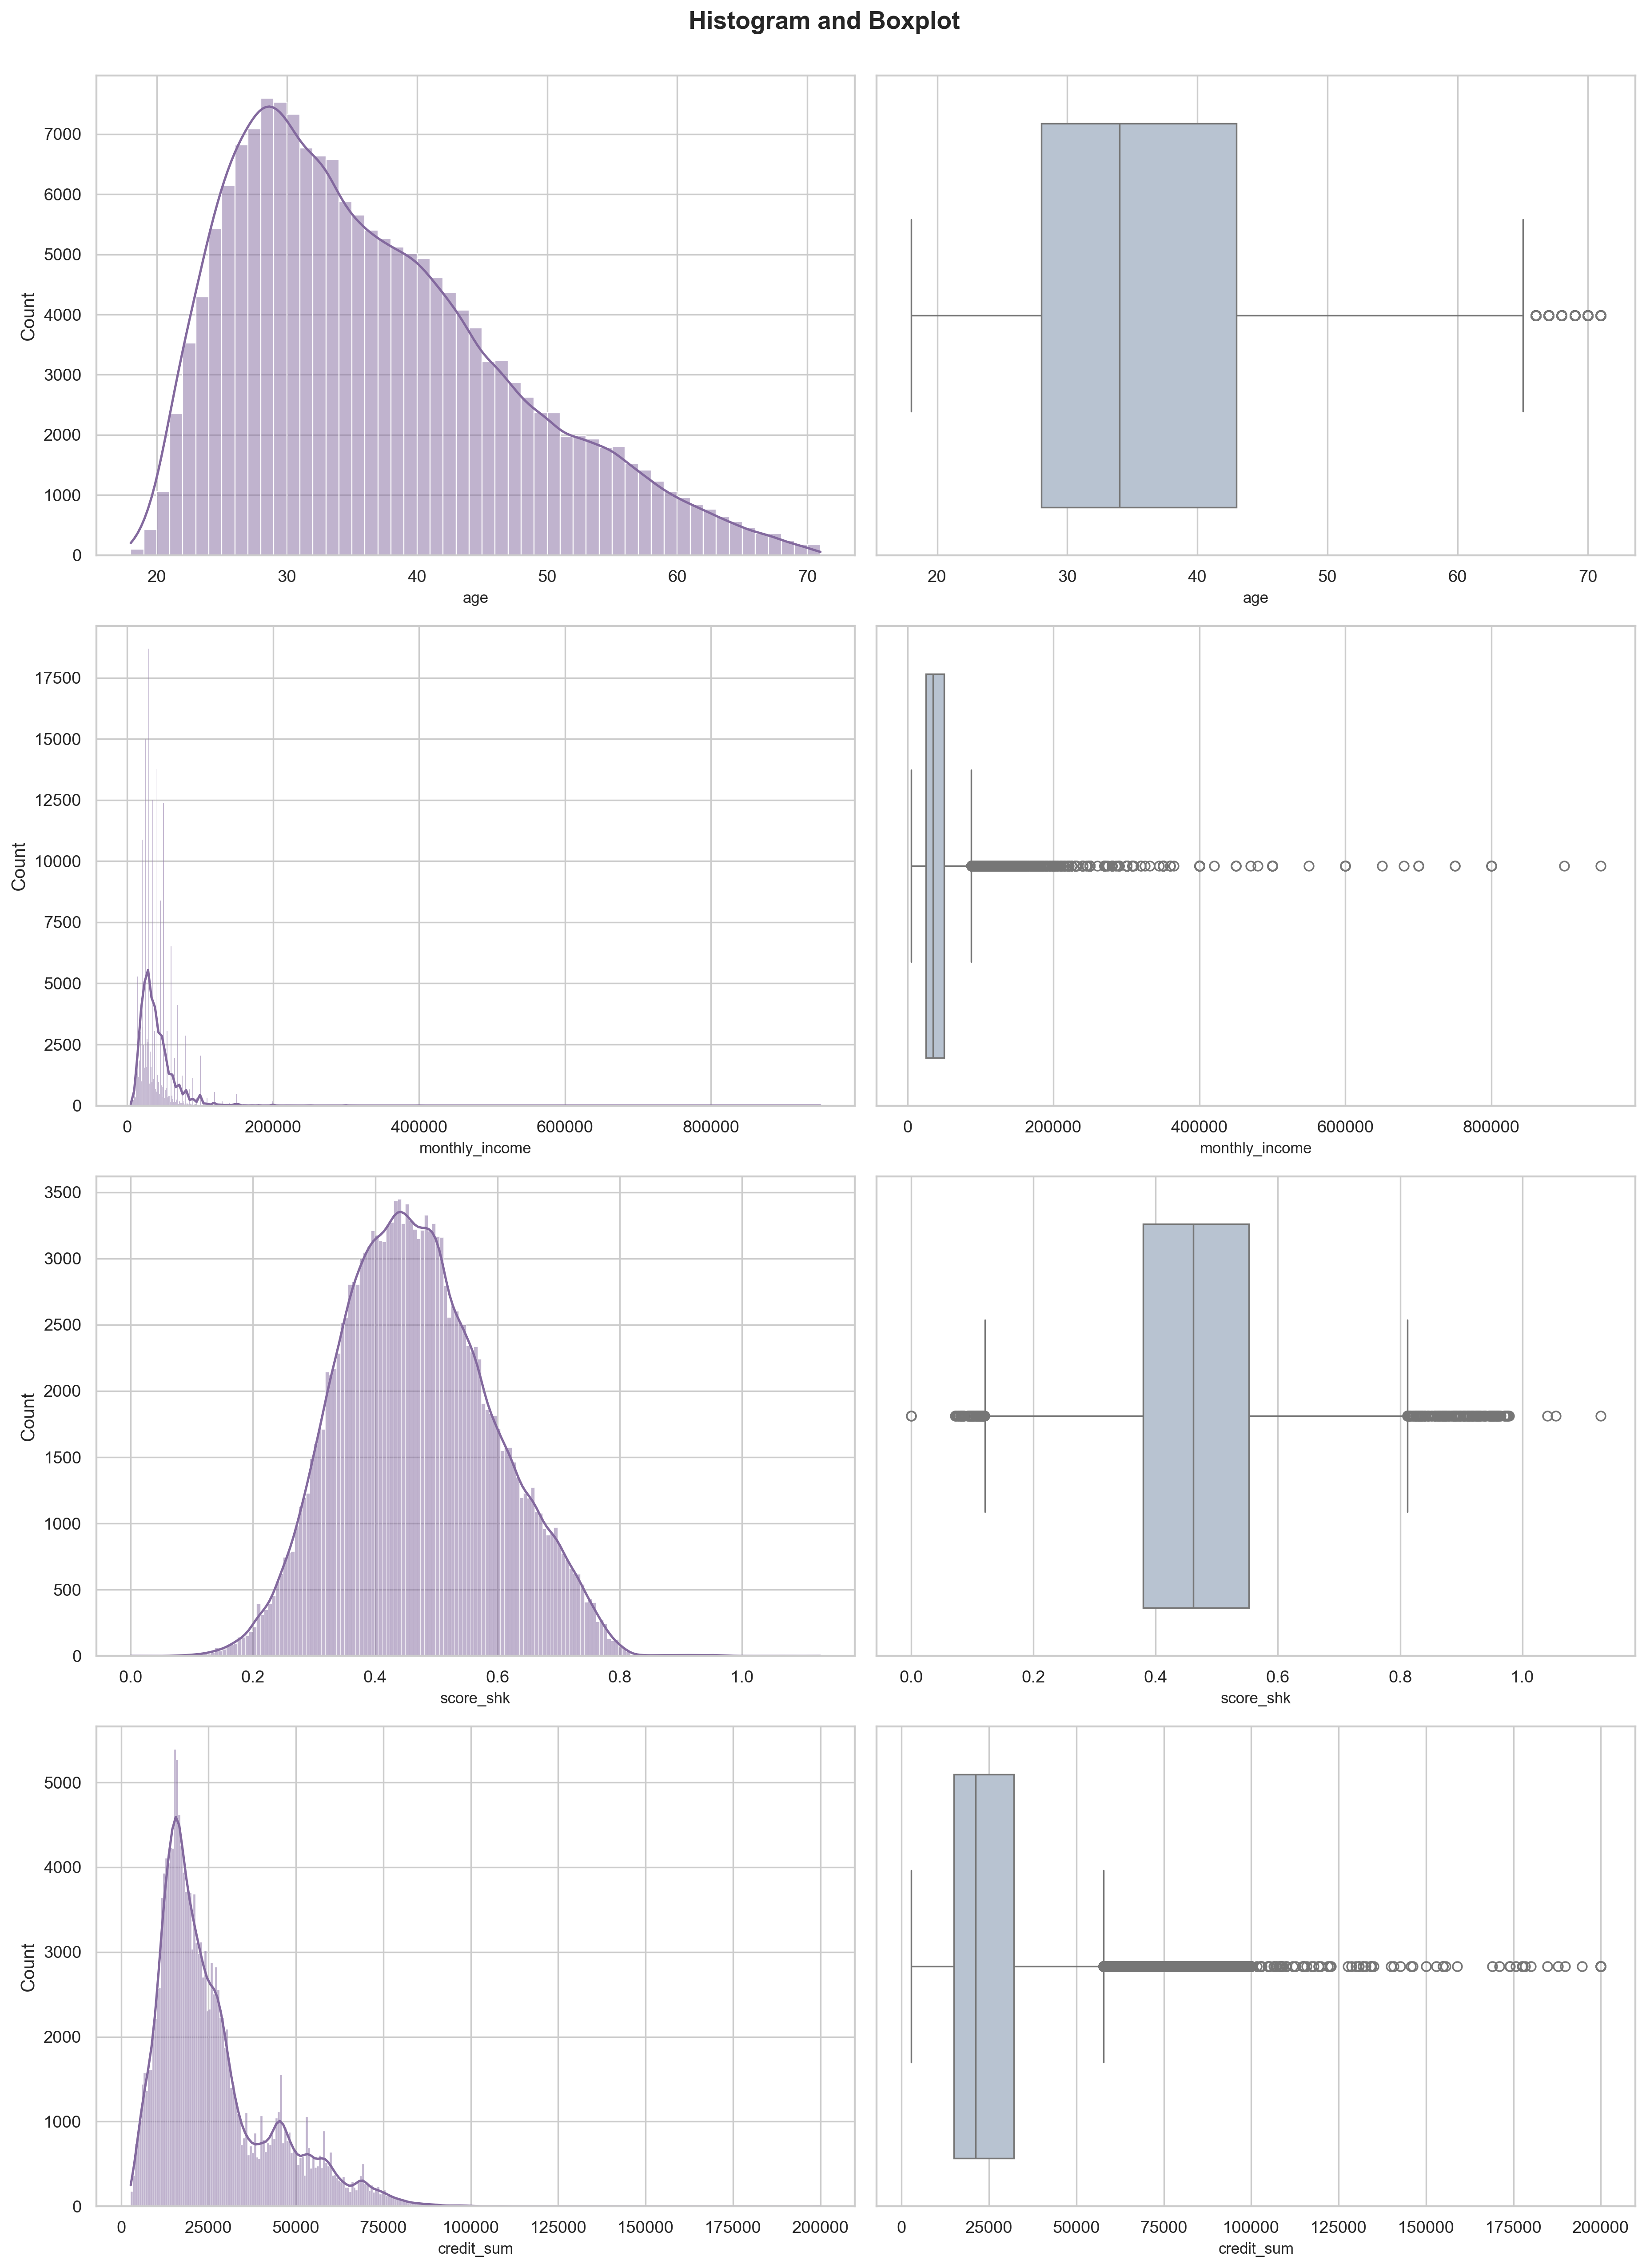

In [134]:
# Визуальный анализ непрерывных признаков

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20), dpi=250)

for i, col in enumerate(numeric_cols[:4]):
    sns.histplot(
        data=data,
        x=col,
        kde=True,
        ax=axes[i, 0],
        color="#83699e",
        binwidth=1 if col == "age" else None,
    )
    axes[i, 0].set_xlabel(col, fontsize=10)
    sns.boxplot(
        data=data,
        x=col,
        ax=axes[i, 1],
        color="#B4C3D5",
    )

    axes[i, 1].set_xlabel(col, fontsize=10)
    axes[i, 1].set_ylabel("")

plt.tight_layout()
fig.suptitle("Histogram and Boxplot", fontsize=16, fontweight="bold", y=1.02)
plt.show()

Визуальный анализ подтвердил результаты дескриптивного анализа. 

- Особенно наглядны графики для `score_shk`: значения в районе 0 и >1.0 являются редкими единичными аномалиями на фоне почти нормального распределения основной массы клиентов.
- На гистограмме для сумм кредита наблюдаются локальные максимумы в районе примерно 45 тыс.руб. и 70 тыс.руб. Большое количество выбросов подтверждает вывод о наличии редких займов крупных сумм.

In [135]:
# Обработка score_shk
data.query("score_shk > 1 or score_shk == 0")

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,score_shk,education,tariff_id,living_region,district,avg_income,monthly_income,credit_count,overdue_credit_count,open_account_flg,date_bank
15009,15010,2,27.0000,4.0000,14,"44,389.0000",10,0.0000,4.0000,2,31.0000,7.0000,"42,460.0000","40,000.0000",0.0000,0.0000,0,2015-09-18
21127,21128,1,19.0000,4.0000,14,"17,838.6400",12,1.1283,4.0000,28,52.0000,3.0000,"39,380.0000","25,000.0000",NaN,NaN,0,2021-05-21
46866,46867,2,24.0000,4.0000,14,"49,579.0000",10,1.0547,4.0000,28,31.0000,7.0000,"42,460.0000","47,000.0000",NaN,NaN,1,2015-06-12
80686,80687,2,20.0000,4.0000,14,"19,979.0000",10,0.0000,4.0000,2,31.0000,7.0000,"42,460.0000","35,000.0000",NaN,NaN,0,2017-11-17
131437,131438,1,25.0000,4.0000,14,"18,668.0000",10,1.0411,2.0000,19,73.0000,6.0000,"56,000.0000","35,000.0000",NaN,NaN,1,2017-07-28


Общее число записей с аномальными значениями скоринга - 5. В таком случае самая оптимальная опция - удаление.

Дополнительный аргумент в пользу этой стратегии: у 4-х записей имеются пропуски в "проблемных" столбцах `credit_count` и `overdue_credit_count`. 

In [136]:
idx_to_drop = data.query("score_shk > 1 or score_shk == 0").index
data.drop(index=idx_to_drop, inplace=True)

##### Проверка данных в контексте кредитных платежей

Сделаем предположение, что тип платежей по кредиту -  _аннуитетный_, т.е. кредит погашается равными платежами.

В банковской сфере главный ограничитель при оформлении кредита - __показатель долговой нагрузки (Payment-to-Income, PTI).__ Если платеж по кредиту превышает __50%__ (допущение для нашей задачи) от официального дохода, то клиент попадает в категорию заемщиков с высокой долговой нагрузкой.

Формула расчета аннуитетного платежа:
$$A = S \times \frac{r \cdot (1 + r)^n}{(1 + r)^n - 1}, $$
где $A$ - размер платежа, $S$ - сумма выданного кредита, $r$ - месячная процентная ставка, $n$ - срок кредита в месяцах.

Допущение: годовая процентная ставка равна __15%__. Чтобы получить $r$, это значение надо поделить на 12 и 100.

In [137]:
rate = 0.15 / 12
data["monthly_payment"] = data.apply(
    lambda row: row["credit_sum"]
    * (
        rate
        * (1 + rate) ** (row["credit_month"])
        / ((1 + rate) ** (row["credit_month"]) - 1)
    ),
    axis=1,
)

data["pti"] = data["monthly_payment"] / data["monthly_income"]

In [138]:
high_debt_clients = data.query("pti > 0.5")

print(
    f"Количество заемщиков с PTI > 50%: {high_debt_clients.shape[0]}\n"
    f"Их доля относительно общей выборки: {high_debt_clients.shape[0] / data.shape[0] * 100:.2f}%"
)

Количество заемщиков с PTI > 50%: 26
Их доля относительно общей выборки: 0.02%

In [139]:
# Для удобства восприятия тысяч
pd.options.display.float_format = "{:,.4f}".format

cols = [
    "score_shk",
    "monthly_income",
    "monthly_payment",
    "credit_sum",
    "credit_month",
    "pti",
    "credit_count",
    "overdue_credit_count",
]

high_debt_clients[cols].sort_values(by="pti", ascending=False)

,score_shk,monthly_income,monthly_payment,credit_sum,credit_month,pti,credit_count,overdue_credit_count
35089,0.4218,"20,000.0000","40,969.9706","119,900.0000",3,2.0485,2.0000,0.0000
57128,0.3578,"10,000.0000","15,253.6548","169,000.0000",12,1.5254,3.0000,0.0000
134468,0.2639,"10,000.0000","12,062.0514","35,300.0000",3,1.2062,1.0000,0.0000
34964,0.3861,"6,000.0000","5,951.9563","34,200.0000",6,0.9920,4.0000,0.0000
22605,0.2106,"19,000.0000","15,681.0085","45,891.0000",3,0.8253,0.0000,0.0000
128458,0.5760,"14,000.0000","11,481.1594","33,600.0000",3,0.8201,NaN,NaN
169072,0.3033,"5,000.0000","3,983.9528","15,450.0000",4,0.7968,1.0000,0.0000
120923,0.4216,"5,000.0000","3,879.4167","80,010.0000",24,0.7759,3.0000,0.0000
98449,0.4967,"7,000.0000","5,254.0807","30,190.0000",6,0.7506,NaN,NaN
5523,0.4223,"10,200.0000","6,830.6064","19,990.0000",3,0.6697,1.0000,1.0000


| Аномалия | Примеры (id) | Суть | 
| --: | :-- | :-- |
| Сверхкороткий срок (3 месяца) | `5523`,  `239`, `134419`, `284` | Самая большая группа заемщиков. Из-за короткого срока кредитования ежемесячный платеж выше, что и дает высокий PTI. Вероятно, эти клиенты планируют погасить долг досрочно. |
| Экстремально низкий доход (до 6000 руб.) | `34964`, `169072`, `120923` | Высока вероятность, что доход указан "для галочки", и банк учитывает другие факторы при оформлении кредита (напр., неофициальный заработок). |
| pti > 1 | `35089`, `57128`, `134468` | Ежемесячный платеж больше официальной зарплаты. Одобрение кредита возможно, если эти клиенты внесли крупный залог, привлекли созаемщиков или имеют неофициальный доход. |

##### Промежуточный вывод
Рассмотренные "аномалии" в виде заемщиков с высокой долговой нагрузкой отражают специфику одобрения кредита (в частности, с учетом альтернативного дохода), а не сбой в данных. 

Важно подчеркнуть, что `monthly_income` _не всегда полностью отражает реальный уровень платежеспособности клиента._

##### Проверка данных на логические противоречия
1) Минимальное значение кредита - 1, значения 0 в `credit_count` быть не может.
2) Просрочек больше, чем кредитов.
3) Активный кредит при пустой истории (NaN у `credit_count` и `overdue_credit_count`).

In [140]:
data.query("credit_count == 0").shape[0]

25805

In [141]:
data["credit_count"] = data["credit_count"].replace(0, 1)

In [142]:
data.query("overdue_credit_count > credit_count").shape[0]

0

In [143]:
data.query(
    "credit_count.isnull() and overdue_credit_count.isnull() and credit_sum > 0"
).shape[0]

9226

Большое количество записей может сигнализировать о техническом сбое или отказе системы при запросе в БКИ (бюро кредитных историй). Возможно, это _новые клиенты без кредитной истории_. Проверим на показатели PTI:

In [144]:
no_history = data.query(
    "credit_count.isnull() and overdue_credit_count.isnull() and credit_sum > 0"
)

s1 = data.drop(index=no_history.index)["pti"].describe(percentiles=per)
s2 = no_history["pti"].describe(percentiles=per)

table1 = Table(
    title="Описательная статистика pti клиентов с историей в БКИ", title_style="bold green"
)
table1.add_column("Метрика", style="cyan")
table1.add_column("Значение", justify="right", style="magenta")
for metric, value in s1.items():
    table1.add_row(str(metric), f"{value:.4f}")
    
table2 = Table(
    title="Описательная статистика pti клиентов без истории в БКИ", title_style="bold green"
)
table2.add_column("Метрика", style="cyan")
table2.add_column("Значение", justify="right", style="magenta")
for metric, value in s2.items():
    table2.add_row(str(metric), f"{value:.4f}")

print(Columns([table1, table2]))

 Описательная статистика  Описательная статистика
pti клиентов с историей в    pti клиентов без    
           БКИ                 истории в БКИ     
┏━━━━━━━━━┳━━━━━━━━━━━━━┓ ┏━━━━━━━━━┳━━━━━━━━━━━┓
┃ Метрика ┃    Значение ┃ ┃ Метрика ┃  Значение ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━┩ ┡━━━━━━━━━╇━━━━━━━━━━━┩
│ count   │ 161512.0000 │ │ count   │ 9226.0000 │
│ mean    │      0.0746 │ │ mean    │    0.0936 │
│ std     │      0.0454 │ │ std     │    0.0540 │
│ min     │      0.0011 │ │ min     │    0.0029 │
│ 10%     │      0.0290 │ │ 10%     │    0.0384 │
│ 25%     │      0.0428 │ │ 25%     │    0.0558 │
│ 50%     │      0.0642 │ │ 50%     │    0.0825 │
│ 75%     │      0.0950 │ │ 75%     │    0.1204 │
│ 90%     │      0.1343 │ │ 90%     │    0.1641 │
│ 95%     │      0.1631 │ │ 95%     │    0.1913 │
│ 99%     │      0.2206 │ │ 99%     │    0.2461 │
│ max     │      2.0485 │ │ max     │    0.8201 │
└─────────┴─────────────┘ └─────────┴───────────┘

##### Анализ долговой нагрузки «новичков» (сегмент с NaN в БКИ)

Клиенты без кредитной истории в БКИ (9 226 человек) обладают системно более высокой долговой нагрузкой (PTI): их медианный показатель составляет 0.0825 против 0.0642 у клиентов с историей, а 75%-й перцентиль смещен к 0.1204 против 0.0950. 

Это может указывать на то, что «новичко» имеюи более крупные ежемесячные платежи относительно своего дохода.

In [145]:
cols = ["age", "score_shk", "credit_sum", "monthly_payment", "credit_month"]

no_history[cols].describe(percentiles=per)

,age,score_shk,credit_sum,monthly_payment,credit_month
count,"9,226.0000","9,226.0000","9,226.0000","9,226.0000","9,226.0000"
mean,26.9847,0.5477,"28,907.9805","2,988.8253",10.8093
std,8.3239,0.1360,"16,691.3278","1,786.0262",3.4301
min,18.0000,0.1352,"3,000.0000",294.2421,3.0000
10%,20.0000,0.3641,"11,661.0000","1,236.5962",8.0000
25%,22.0000,0.4506,"16,228.2500","1,700.4892",10.0000
50%,24.0000,0.5507,"24,762.4350","2,484.3974",10.0000
75%,29.0000,0.6574,"39,990.0000","3,925.0181",12.0000
90%,39.0000,0.7252,"53,878.5000","5,500.3736",12.0000
95%,45.0000,0.7518,"61,374.7500","6,372.6938",18.0000


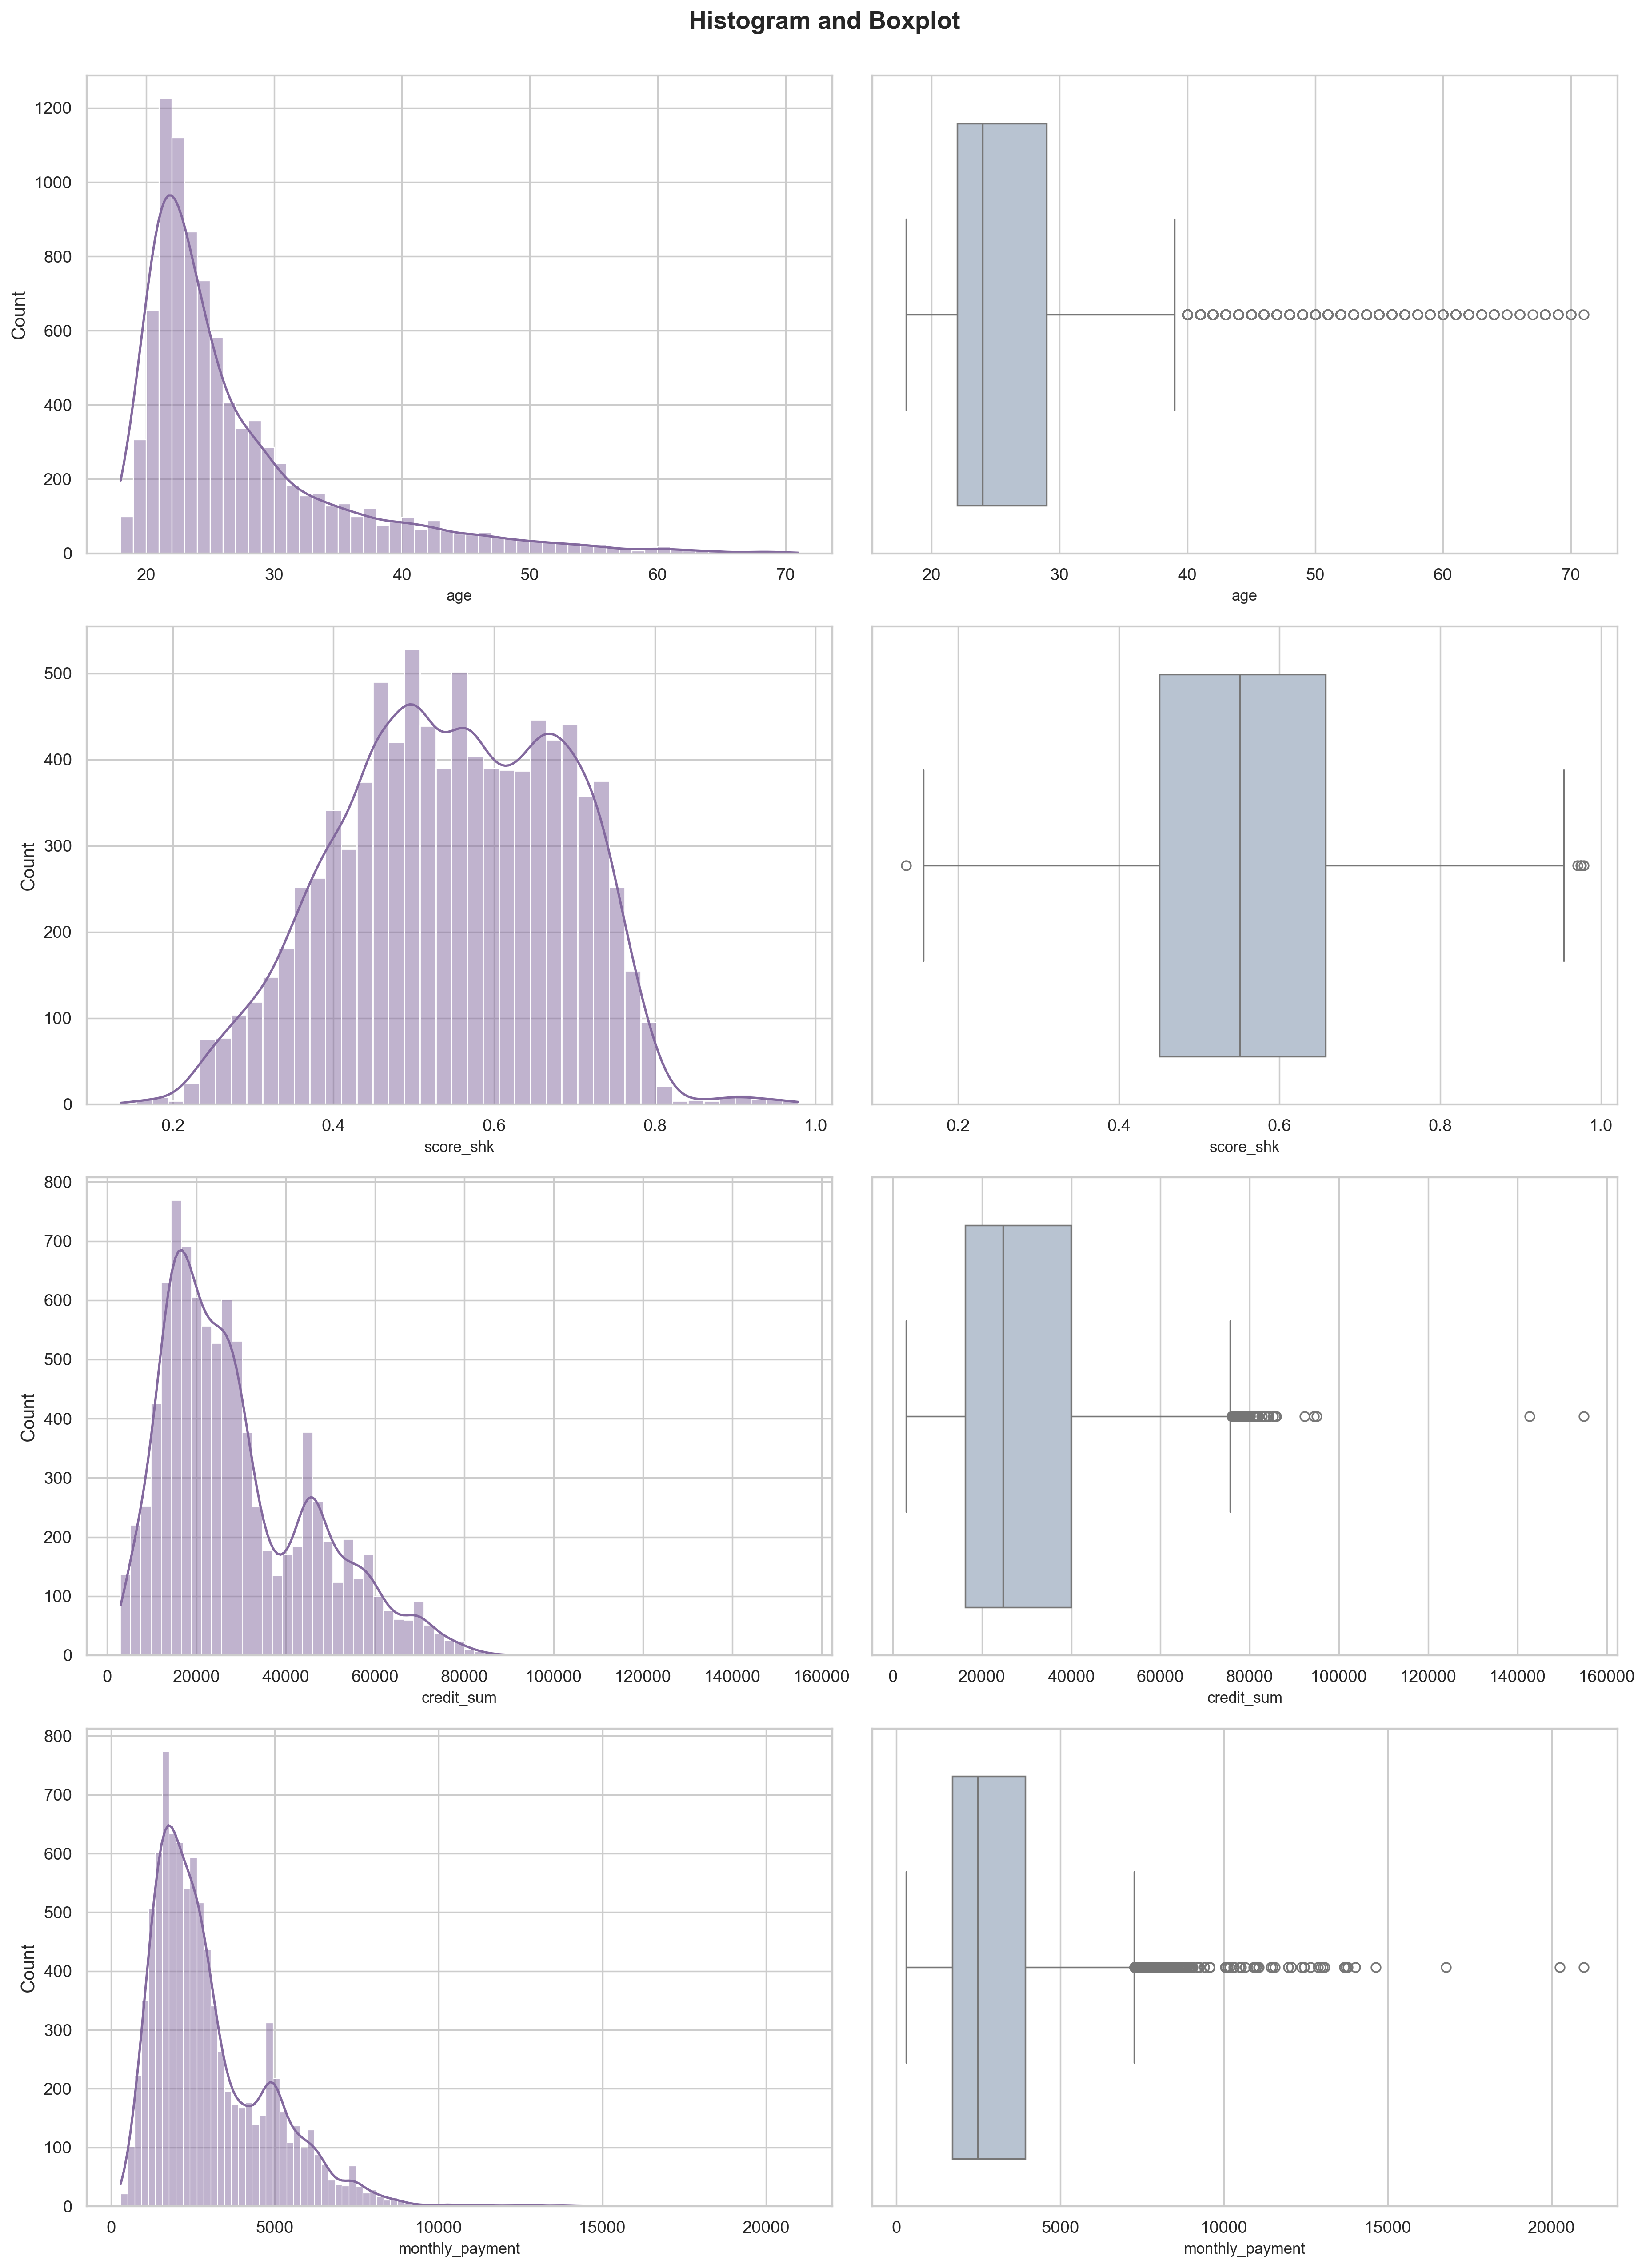

In [146]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20), dpi=250)

for i, col in enumerate(cols[:4]):
    sns.histplot(
        data=no_history,
        x=col,
        kde=True,
        ax=axes[i, 0],
        color="#83699e",
        binwidth=1 if col == "age" else None,
    )
    axes[i, 0].set_xlabel(col, fontsize=10)

    sns.boxplot(
        data=no_history,
        x=col,
        ax=axes[i, 1],
        color="#B4C3D5",
    )

    axes[i, 1].set_xlabel(col, fontsize=10)
    axes[i, 1].set_ylabel("")

plt.tight_layout()
fig.suptitle("Histogram and Boxplot", fontsize=16, fontweight="bold", y=1.02)
plt.show()

##### Анализ клиентов с пропусками в БКИ
- `age`: Смещение в пользу молодежи. Медианный возраст - 24 года (в общей выборке он составляет 34), 75% группы младше 29 лет (43 года по всей выборке). На гистограмме наблюдается резкий спад после 30 лет. 
- `score_shk`: Медианное (0.5507) и среднее (0.5477) значения практически равны. Банк оценивает этих клиентов как "стабильных" по уровню надежности. Распределение близко к симметричному, точки ниже 0.139 и выше 0.968 отображены как выбросы на боксплоте.
- `credit_sum`: Суммы выдаваемых кредитов консервативны, медианное значение - 24 762 руб., 90% группы оформляют кредит не более 54 тыс. руб. На боксплоте наблюдаются выбросы за пределами 99-го перцентиля. Максимальное значение - 154 800 руб.
- `monthly_payment`: Суммы выплат у этой группы клиентов небольшие - для половины клиентов платеж не превышает 2 484 руб., для 75% выплаты ограничены планкой в 3 925 руб. На гистограмме четко виден пик в районе 2000 руб.
- `credit_month`: Высокая концентрация сроков кредитования в узком диапазоне - медианное значение в 10 месяцев и 75-й перцентиль в 12 месяцев - может говорить о том, что банк предпочитает давать кредит на более долгий срок для клиентов без истории в БКИ (предполагали выше).

##### Вывод
Сегмент клиентов с пропусками в БКИ  представляет собой группу молодых людей, которые впервые берут кредит на небольшую сумму. Кредитование преимущественно на год с комфортным платежом до 2 500 рублей.

Анализ показал, что клиенты с пропусками в  `credit_count` и `overdue_credit_count` образуют отдельный сегмент - "новички" без кредитной истории. 

Поэтому целесообразно добавить бинарный признак `is_new` для разделения клиентов на сегменты.

In [147]:
new_clients_idx = no_history.index

# Добавление нового признака
data["is_new"] = np.where(data.index.isin(new_clients_idx), 1, 0)

In [148]:
# Заполнение пропусков у "новичков"
data.loc[new_clients_idx, "overdue_credit_count"] = 0
data.loc[new_clients_idx, "credit_count"] = 1

##### Обработка пропусков

Региональные данные `living_region`и `avg_income` проверим таким образом: 
- Создадим два списка индексов: для записей с пустыми значениями у `living_region` и `avg_income`. Если списки идентичны, то нет возможности восстановить значения и эти записи надо просто удалить.

In [149]:
indices1 = data[data["living_region"].isna()].index
indices2 = data[data["avg_income"].isna()].index

result = indices1.difference(indices2)

if result.empty:
    print(f"Индексы одинаковы: [bold red]{len(indices1)} записи удалено.[/bold red]")
    data.drop(indices1, inplace=True)
else:
    print(
        "Индексы различаются: [bold green]необходимо дальнейшее исследование.[/bold green]"
    )

Индексы одинаковы: 192 записи удалено.

In [150]:
data.isna().sum()

client_id               0
gender                  0
age                     2
marital_status          5
job_position            0
credit_sum              1
credit_month            0
score_shk               3
education               3
tariff_id               0
living_region           0
district                0
avg_income              0
monthly_income          2
credit_count            0
overdue_credit_count    0
open_account_flg        0
date_bank               0
monthly_payment         1
pti                     3
is_new                  0
dtype: int64

In [151]:
# Простое удаление - пара записей не исказят общую картину
small_nan_cols = [
    "age",
    "marital_status",
    "credit_sum",
    "score_shk",
    "education",
    "monthly_income",
    "monthly_payment",
    "pti",
]

data.dropna(subset=small_nan_cols, inplace=True)

print(data.isna().sum())

client_id               0
gender                  0
age                     0
marital_status          0
job_position            0
credit_sum              0
credit_month            0
score_shk               0
education               0
tariff_id               0
living_region           0
district                0
avg_income              0
monthly_income          0
credit_count            0
overdue_credit_count    0
open_account_flg        0
date_bank               0
monthly_payment         0
pti                     0
is_new                  0
dtype: int64

##### Анализ по очистке пропусков
- Индексы записей с пустыми георгафическими данными (`living_region` и `avg_income`) полностью совпали - восстановление данных было невозможно, поэтому было принято решение удалить 192 записи из датасета.
- Для признаков с малым количеством пропусков (от 1 до 5) с учетом масштаба датасета (170 тыс. записей) также было принято решение удалить соответствующие строки. 

##### Инженерия признаков
Для дальнейшего анализ добавим еще один макроэкономический показатель - __индекс относительного дохода:__ $$\text{income \_ ratio} = \frac{\text{monthly \_ income}}{\text{avg \_ income}}$$

Важное уточнение:

Коэффициент учитывает _официальный заявленный доход клиента_ и не всегда полностью отражает картину, если клиент, например, имеет неофициальные источники дохода или работает "в серую". Наличие таких клиентов было выявлено на этапе исследования показателей PTI.

In [152]:
data["income_ratio"] = data["monthly_income"] / data["avg_income"]

### Исследование социально-демографических признаков

In [153]:
cols_to_explore = [
    "age",
    "gender",
    "marital_status",
    "education",
    "district",
    "living_region",  # Взять ТОП 20
    "job_position",  # Много категорий - лучше визуализировать
]


console.print(
    "Распределение значений социально-демографических признаков по группам клиентов, %",
    style="bold",
    justify="center",
)

tables = []

for col in cols_to_explore[1:5]:
    table = Table(title=f"{col}", title_style="bold green")

    table.add_column("Категория", style="cyan")
    table.add_column("has cc", justify="right", style="magenta")
    table.add_column("no cc", justify="right", style="green")

    grouped_data = (
        data.groupby("open_account_flg")[col]
        .value_counts(normalize=True)
        .reset_index(name="Доля")
    )

    # Поворот таблицы для корректного вывода
    pivot_data = grouped_data.pivot(
        index=col, columns="open_account_flg", values="Доля"
    )

    for value, row in pivot_data.iterrows():
        has_cc_percent = round(row[1] * 100, 2)
        no_cc_percent = round(row[0] * 100, 2)

        table.add_row(str(value), str(has_cc_percent), str(no_cc_percent))

    tables.append(table)

print(Columns(tables, equal=True, expand=True))

                 Распределение значений социально-демографических признаков по группам клиентов, %                 

            gender                             marital_status                           education                  
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓         ┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓         ┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓       
┃ Категория ┃ has cc ┃ no cc ┃         ┃ Категория ┃ has cc ┃ no cc ┃         ┃ Категория ┃ has cc ┃ no cc ┃       
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩         ┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩         ┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩       
│ 1         │  47.16 │ 52.98 │         │ 1.0       │   2.82 │  2.38 │         │ 1.0       │   0.08 │  0.06 │       
│ 2         │  52.84 │ 47.02 │         │ 2.0       │  10.28 │  9.87 │         │ 2.0       │   33.7 │  44.4 │       
└───────────┴────────┴───────┘         │ 3.0       │  47.81 │ 56.57 │         │ 3.0       │   0.36 │  0.33 │       
                                       │ 4.0       │  36.65 │ 29.23 │         │ 4.0       │  59.74 │ 49.45 │       
                                       │ 5.0       │   2.45 │  1.95 │         │ 5.0       │   6.11 │  5.76 │       
                                       └───────────┴────────┴───────┘         └───────────┴────────┴───────┘       
           district                                                                                                
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓                                                                                     
┃ Категория ┃ has cc ┃ no cc ┃                                                                                     
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩                                                                                     
│ 1.0       │   4.93 │  3.98 │                                                                                     
│ 2.0       │  18.58 │ 21.71 │                                                                                     
│ 3.0       │  11.09 │  13.5 │                                                                                     
│ 4.0       │   3.21 │  3.82 │                                                                                     
│ 5.0       │  13.04 │ 10.45 │                                                                                     
│ 6.0       │  13.64 │ 13.13 │                                                                                     
│ 7.0       │  23.94 │ 22.67 │                                                                                     
│ 8.0       │  11.56 │ 10.73 │                                                                                     
└───────────┴────────┴───────┘

* `gender`: Предположим, что значение `1` соответствует мужчинам, `2` - женщинам. В таком случае в группе клиентов, открывших карту, доля женщин составляет 52.84%, мужчин — 47.16%. Различие между группами составляет 5,82 п.п.<sup>1</sup>. 
* `marital_status`: Распределение семейного положения заметно различается между группами `3` и `4`: 
    - Среди клиентов 3-й группы доля не имеющих кредитку составляет 8.76 п.п.;
    - Среди клиентов 4-й групп, наоборот, доля клиентов с кредиткой выше на 7.42 п.п. 
Остальные группы представлены примерно одинакова, разница в распределении составляет не более 0.5 п.п.<sup>2</sup>
* `education`: Наиболее заметные различия в распределениях групп наблюдаются для категорий `2` и `4`: доля категории `2` выше среди клиентов без карт на 10.7 п.п.; доля категории `4` выше среди клиентов с картой на 10.29 п.п.<sup>3</sup>
* `district`: Региональные различия выражены слабо. Провести полноценный анализ по этому признаку невозможно без расшифровки кодировки. 

<small>Считаем, что в кодировке банка значение `4` соответствует высшему образованию.</small>

<sup>1, 2, 3</sup> - проверим гипотезы с помощью критерия хи-квадрат:
- __Нулевая гипотеза__ $H_0$: Признак пола/семейного положения/наличия высшего образования и решение об открытии кредитной карты _независимы_.
- __Альтернативная гипотеза__ $H_1$: Признак пола/семейного положения/наличия высшего образования и решение об открытии кредитной карты _связаны_.

In [154]:
# Добавление бинарных признаков
data["is_married"] = np.where(data["marital_status"] == 3, 1, 0)
data["is_higher_education"] = np.where(data["education"] == 4, 1, 0)

##### Методология проверки гипотез

На больших объемах данных статистические тесты чувствительны к масштабу: даже незначительные отклонения признаются статистически значимыми (p-value $\ll$ уровня значимости). Чтобы избежать этого, перед проверкой гипотез целесообразно отобрать случайную подвыборку с сохранением исходного соотношения классов у целевой переменной `open_account_flg` (82.4% vs 17.6%).

Подвыборку формируем случайным образом, задав параметр `random_state=42` для воспроизводимости результатов.

Для интерпретации результатов у категориальных признаках помимо _p-value_ будем использовать коэффициент _V Крамера_ для оценки __величины эффекта__ (силы связи между двумя категориальными переменными). Значение коэффициента будем интерпретировать по <a href='https://real-statistics.com/chi-square-and-f-distributions/effect-size-chi-square/'>этой статье</a>.


In [155]:
# Отбор 6% строк ~ 10 200 записей
data_sample = data.groupby("open_account_flg", group_keys=False).apply(
    lambda x: x.sample(frac=0.06, random_state=42)
)

In [156]:
from scipy.stats import chi2_contingency
import scipy.stats as stats

for col in ["gender", "is_married", "is_higher_education"]:
    contingency_table = pd.crosstab(data_sample[col], data_sample["open_account_flg"])

    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    # Сила связи
    cramers_v = stats.contingency.association(contingency_table, method="cramer")

    console.print(
        f"[bold green]{col}[/bold green]\n"
        f"p-value: {p:.4f} (Значимо: {p < 0.05})\n"
        f"Количество степеней свободы: {dof}\n"
        f"V Крамера: {cramers_v:.4f}"
    )

gender
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.0459

is_married
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.0755

is_higher_education
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.0691

##### Интерпретация результатов

Все тесты обнаружили статистическая взаимосвязь между конкретным признаком и фактом открытия кредитной карты.

Для уточнения силы связи был рассчитан коэффициент V Крамера: для всех случаев он оказался меньше 0.1, что указывает на _крайне слабую связь_.

__Вывод:__ Пол, семейное положение (в браке), наличие высшего образования - статистически значимые признаки. На практике же их сила связи с открытием кредитной карты невелика. При построении портрета клиента их влияние можно считать _второстепенным_.

In [157]:
for i in [0, 1]:
    region_counts = data.query("open_account_flg == @i")["living_region"].value_counts()
    region_percents = (
        data.query("open_account_flg == @i")["living_region"].value_counts(
            normalize=True
        )
        * 100
    )

    console = Console()
    console.print(
        f"open_account_flg = {i}",
        style="bold",
        justify="left",
    )

    data1 = region_counts.iloc[:10]
    data2 = region_counts.iloc[10:20]

    table1 = Table()
    table1.add_column("Регион")
    table1.add_column("Количество", style="cyan")
    table1.add_column("Процент", justify="right", style="magenta")

    for item, count in data1.items():
        pct = region_percents[item]
        table1.add_row(str(item), str(count), f"{pct:.4f}%")

    table2 = Table()
    table2.add_column("Регион")
    table2.add_column("Количество", style="cyan")
    table2.add_column("Процент", justify="right", style="magenta")

    for item, count in data2.items():
        pct = region_percents[item]
        table2.add_row(str(item), str(count), f"{pct:.4f}%")

    print(Columns([table1, table2]))

open_account_flg = 0                                                                                               

┏━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Регион ┃ Количество ┃ Процент ┃ ┃ Регион ┃ Количество ┃ Процент ┃
┡━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ 31.0   │ 10584      │ 7.5341% │ │ 68.0   │ 4162       │ 2.9627% │
│ 30.0   │ 7343       │ 5.2270% │ │ 60.0   │ 3472       │ 2.4715% │
│ 63.0   │ 7074       │ 5.0355% │ │ 14.0   │ 3388       │ 2.4117% │
│ 73.0   │ 6998       │ 4.9814% │ │ 33.0   │ 3043       │ 2.1661% │
│ 23.0   │ 6680       │ 4.7551% │ │ 40.0   │ 3023       │ 2.1519% │
│ 57.0   │ 6537       │ 4.6533% │ │ 27.0   │ 2942       │ 2.0942% │
│ 66.0   │ 6123       │ 4.3586% │ │ 24.0   │ 2491       │ 1.7732% │
│ 46.0   │ 5531       │ 3.9372% │ │ 9.0    │ 2409       │ 1.7148% │
│ 62.0   │ 4492       │ 3.1976% │ │ 4.0    │ 2399       │ 1.7077% │
│ 77.0   │ 4200       │ 2.9897% │ │ 20.0   │ 2298       │ 1.6358% │
└────────┴────────────┴─────────┘ └────────┴────────────┴─────────┘

open_account_flg = 1                                                                                               

┏━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Регион ┃ Количество ┃ Процент ┃ ┃ Регион ┃ Количество ┃ Процент ┃
┡━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ 31.0   │ 2256       │ 7.5070% │ │ 60.0   │ 856        │ 2.8484% │
│ 30.0   │ 1917       │ 6.3789% │ │ 33.0   │ 651        │ 2.1662% │
│ 73.0   │ 1735       │ 5.7733% │ │ 24.0   │ 630        │ 2.0964% │
│ 23.0   │ 1674       │ 5.5703% │ │ 62.0   │ 612        │ 2.0365% │
│ 63.0   │ 1228       │ 4.0863% │ │ 20.0   │ 592        │ 1.9699% │
│ 66.0   │ 1193       │ 3.9698% │ │ 40.0   │ 590        │ 1.9633% │
│ 57.0   │ 1130       │ 3.7601% │ │ 27.0   │ 587        │ 1.9533% │
│ 77.0   │ 954        │ 3.1745% │ │ 68.0   │ 455        │ 1.5140% │
│ 14.0   │ 935        │ 3.1113% │ │ 8.0    │ 413        │ 1.3743% │
│ 46.0   │ 934        │ 3.1079% │ │ 35.0   │ 412        │ 1.3710% │
└────────┴────────────┴─────────┘ └────────┴────────────┴─────────┘

##### Топ-5 регионов по группам

| Место | has cc | no cc | 
| --: | :-- | :-- |
| 1 | 31 (7.5%) | 31 (7.53%) |
| 2 | 30 (6.38%) | 30 (5.23%) |
| 3 | 73 (5.77%) | 63 (5.04%) |
| 4 | 23 (5.57%) | 73 (4.98%) |
| 5 | 63 (4.09%) | 23 (4.76%) |

Состав регионов-лидеров практически идентичен: первые два места делят регионы с кодами `31` и `30`. Суммарно на топ-5 регионов приходится 29.3% открытых кредиток и 27.5% неоткрытых. 

Выраженных различий в региональных распределениях между группами не обнаружено. Для дальнейшей характеристики регионального контекста далее используется созданный на этапе инженерии признаков индекс относительного дохода `income_ratio`.

In [158]:
job_data = (
    data.groupby("open_account_flg")["job_position"]
    .value_counts(normalize=True)
    .reset_index(name="Доля")
)
job_data["Процент"] = job_data["Доля"] * 100

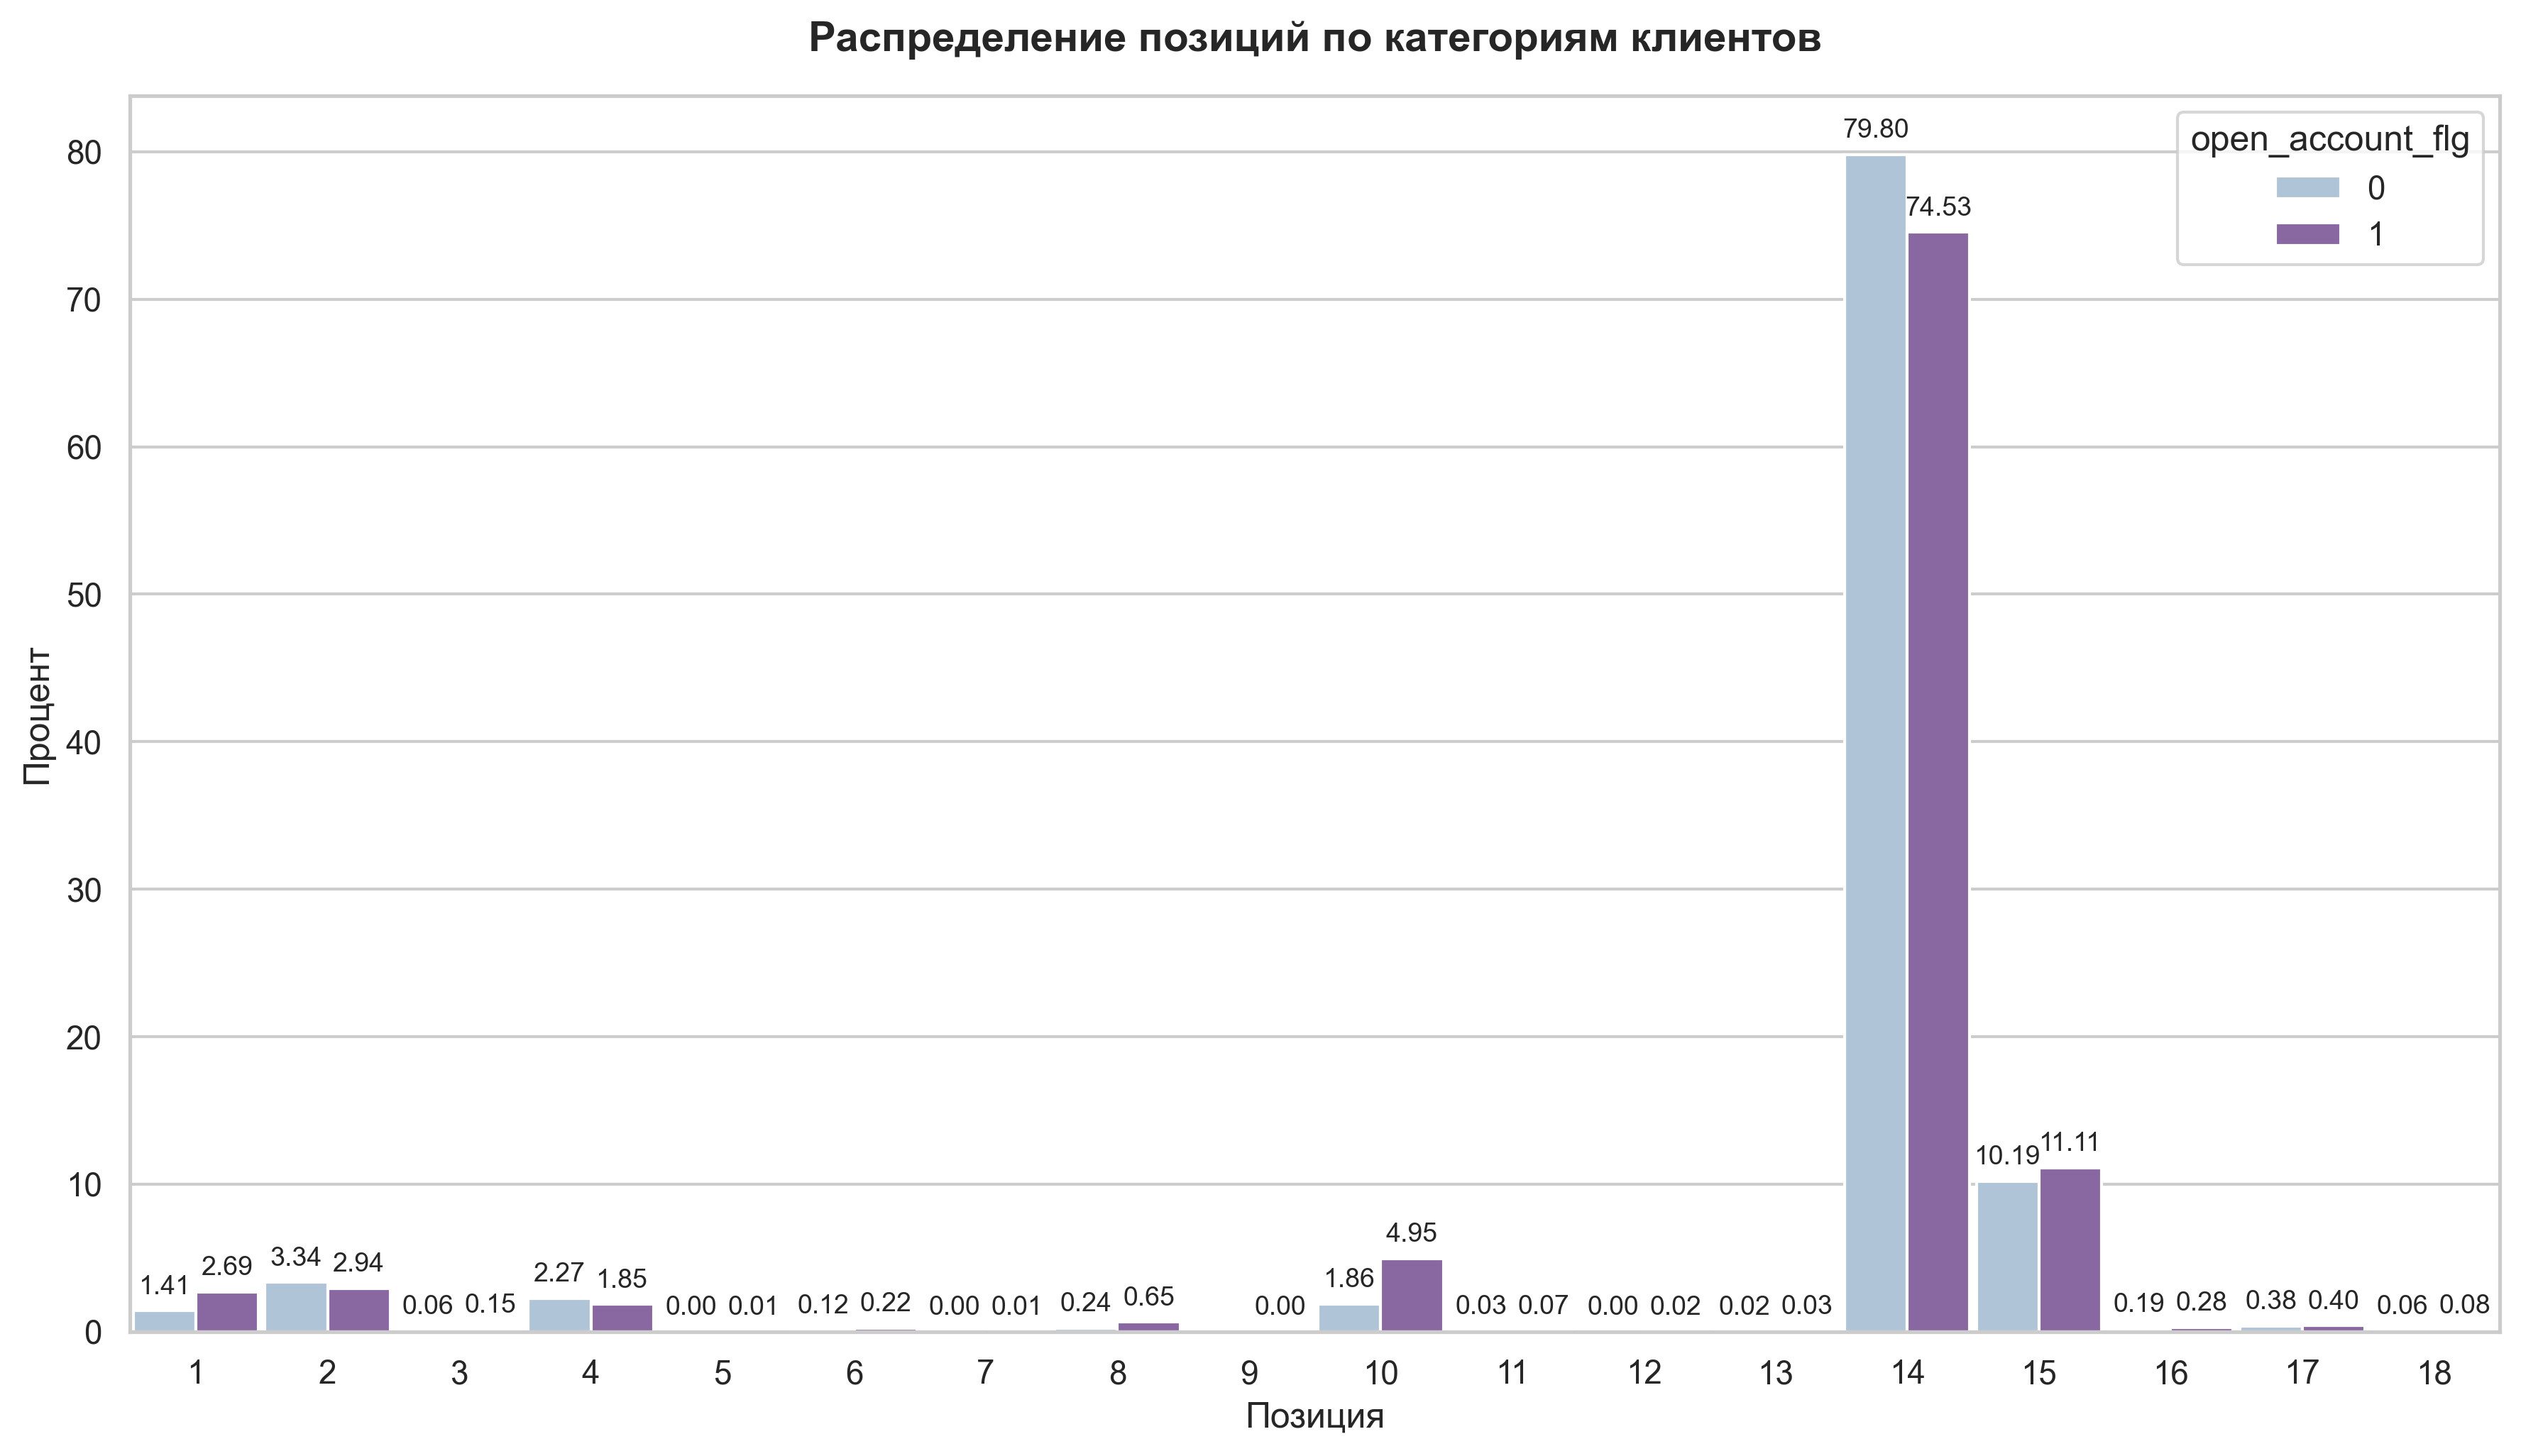

In [159]:
plt.figure(figsize=(12, 7), dpi=300)

ax = sns.barplot(
    data=job_data,
    x="job_position",
    y="Процент",
    hue="open_account_flg",
    palette="BuPu",
    width=0.95,
)

plt.title(
    "Распределение позиций по категориям клиентов",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Позиция", fontsize=12)
plt.ylabel("Процент", fontsize=12)


for container in ax.containers:

    labels = [f"{v.get_height():.2f}" for v in container]

    ax.bar_label(
        container,
        labels=labels,
        padding=4,
        fontsize=9,
    )

plt.tight_layout()
plt.show()

##### Профессиональное распределение
В обеих группах доминирует категория `14`: 74.53% и 79.8% для открывших и не открывших кредитную карту соответственно. Оценим распределение топ-5 категорий `job_position`:

| Место | has cc | no cc | 
| --: | :-- | :-- |
| 1 | 14 (74.53%) | 14 (79.8%) |
| 2 | 15 (11.11%) | 15 (10.19%) |
| 3 | 10 (4.95%) | 2 (3.34%) | 
| 4 | 2 (2.94%) | 4 (2.27%) |
| 5 | 1 (2.69%) | 10 (1.86%) |

Состав пяти наиболее распространённых категорий в обеих группах практически совпадает, но среди них есть структурные различия:
- `10` позиция смещена в сторону открытия карт. Ее доля в группе `has cc` в 2.7 раза выше, чем во второй группе (4.95% vs 1.86%).
- Категория `1` имеет больший интерес к кредитным картам, чем категория `2`.

Проверим на наличие статистической связи между позицией `10` и фактом открытия кредитной карты:

In [160]:
data_sample["is_job_10"] = np.where(data_sample["job_position"] == 10, 1, 0)

contingency_table = pd.crosstab(
    data_sample["is_job_10"], data_sample["open_account_flg"]
)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
cramers_v = stats.contingency.association(contingency_table, method="cramer")

console.print(
    f"[bold green]is_job_10[/bold green]\n"
    f"p-value: {p:.4f} (Значимо: {p < 0.05})\n"
    f"Количество степеней свободы: {dof}\n"
    f"V Крамера: {cramers_v:.4f}"
)

is_job_10
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.0742

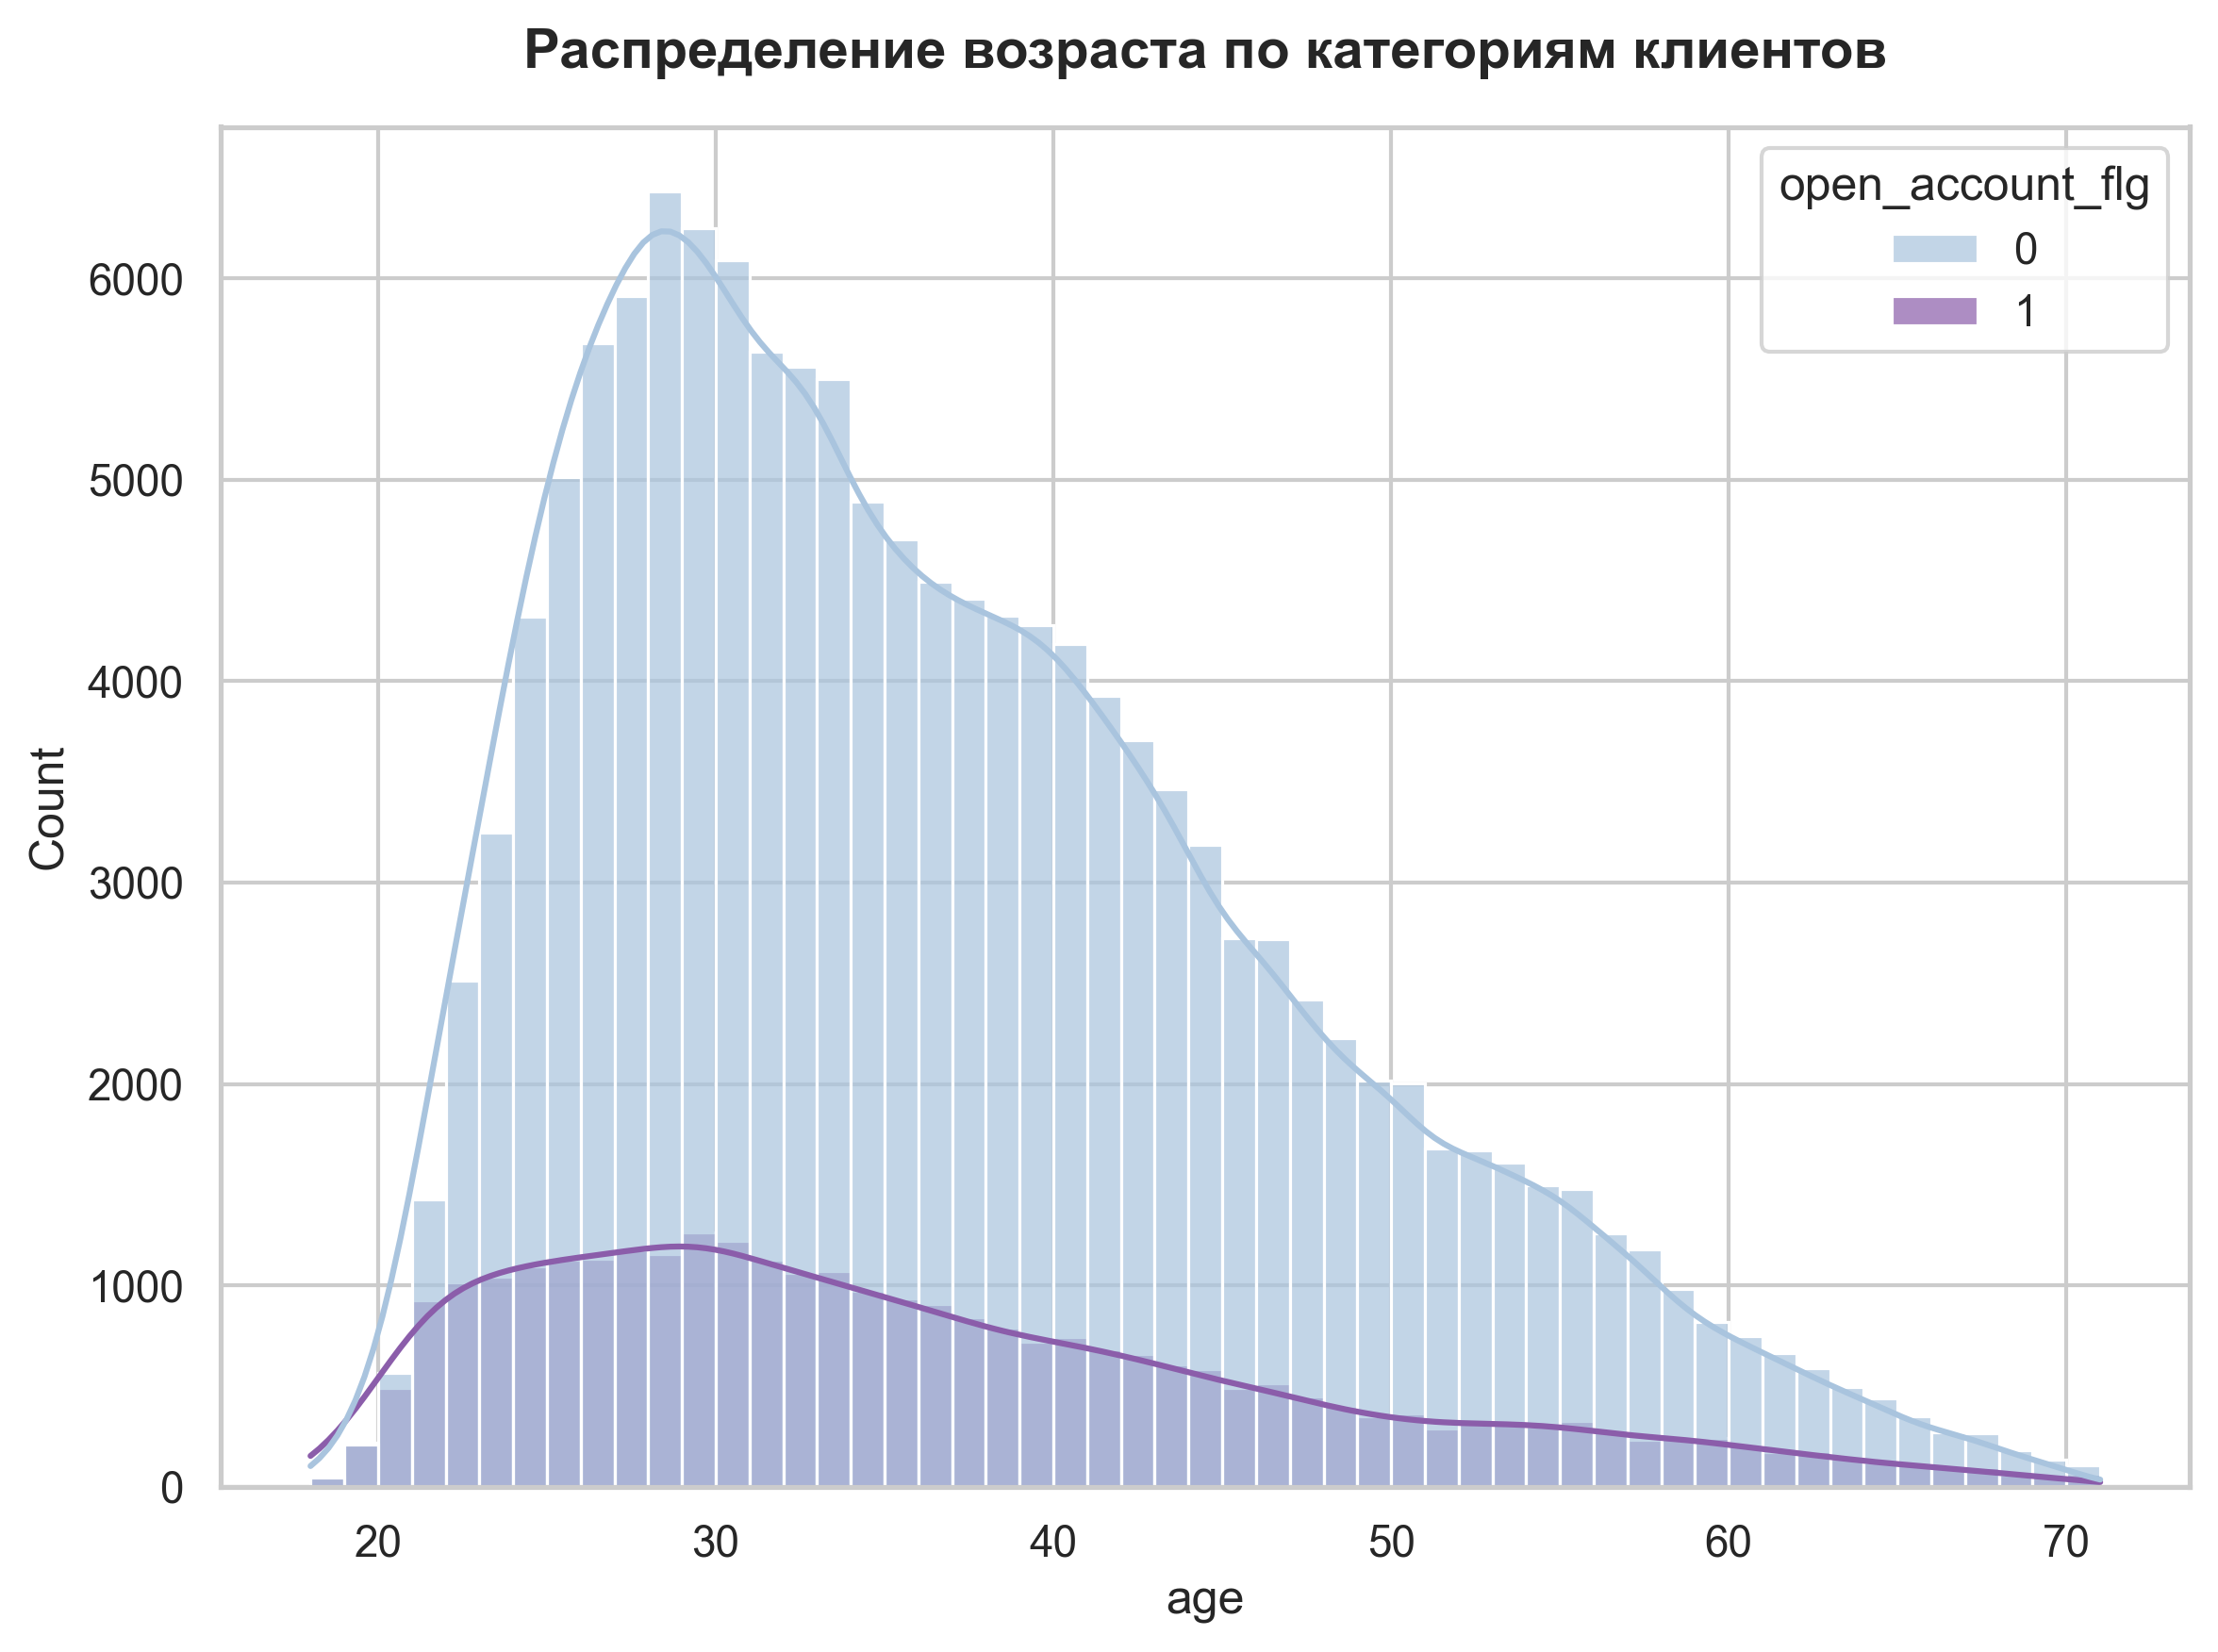

In [161]:
plt.figure(figsize=(8, 6), dpi=300)

ax = sns.histplot(
    data=data,
    x="age",
    hue="open_account_flg",
    multiple="layer",
    kde=True,
    palette="BuPu",
    alpha=0.7,
    binwidth=1,
)

plt.title(
    "Распределение возраста по категориям клиентов",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("age", fontsize=12)


plt.tight_layout()
plt.show()

In [162]:
data.groupby("open_account_flg")["age"].describe(percentiles=per)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
open_account_flg,,,,,,,,,,,,
0,"140,482.0000",36.6523,10.3426,18.0000,25.0000,28.0000,35.0000,43.0000,52.0000,57.0000,64.0000,71.0000
1,"30,052.0000",35.7896,11.4283,18.0000,23.0000,27.0000,33.0000,43.0000,53.0000,59.0000,66.0000,71.0000


##### Анализ распределения возраста клиентов
- Гистограммы для обеих групп имеют асимметрию с перекосом в сторону молодых клиентов. Основной пик приходится на значения в районе 30 - 35 лет, после наблюдается плавный спад к 71 году. 
- Средний и медианный возраст у клиентов с кредиткой немного ниже: 35.79 vs 36.65 и 33 vs 35. 

Ниже проведем статистическое тестирование, чтобы определить, случаен этот сдвиг или нет.
 

### Исследование экономических признаков

In [163]:
cols_to_explore = [
    "monthly_income",
    "income_ratio",
    "credit_sum",
    "credit_month",
    "monthly_payment",
    "pti",
]

stats1 = data.query("open_account_flg == 0")[cols_to_explore].describe(percentiles=per)
stats2 = data.query("open_account_flg == 1")[cols_to_explore].describe(percentiles=per)

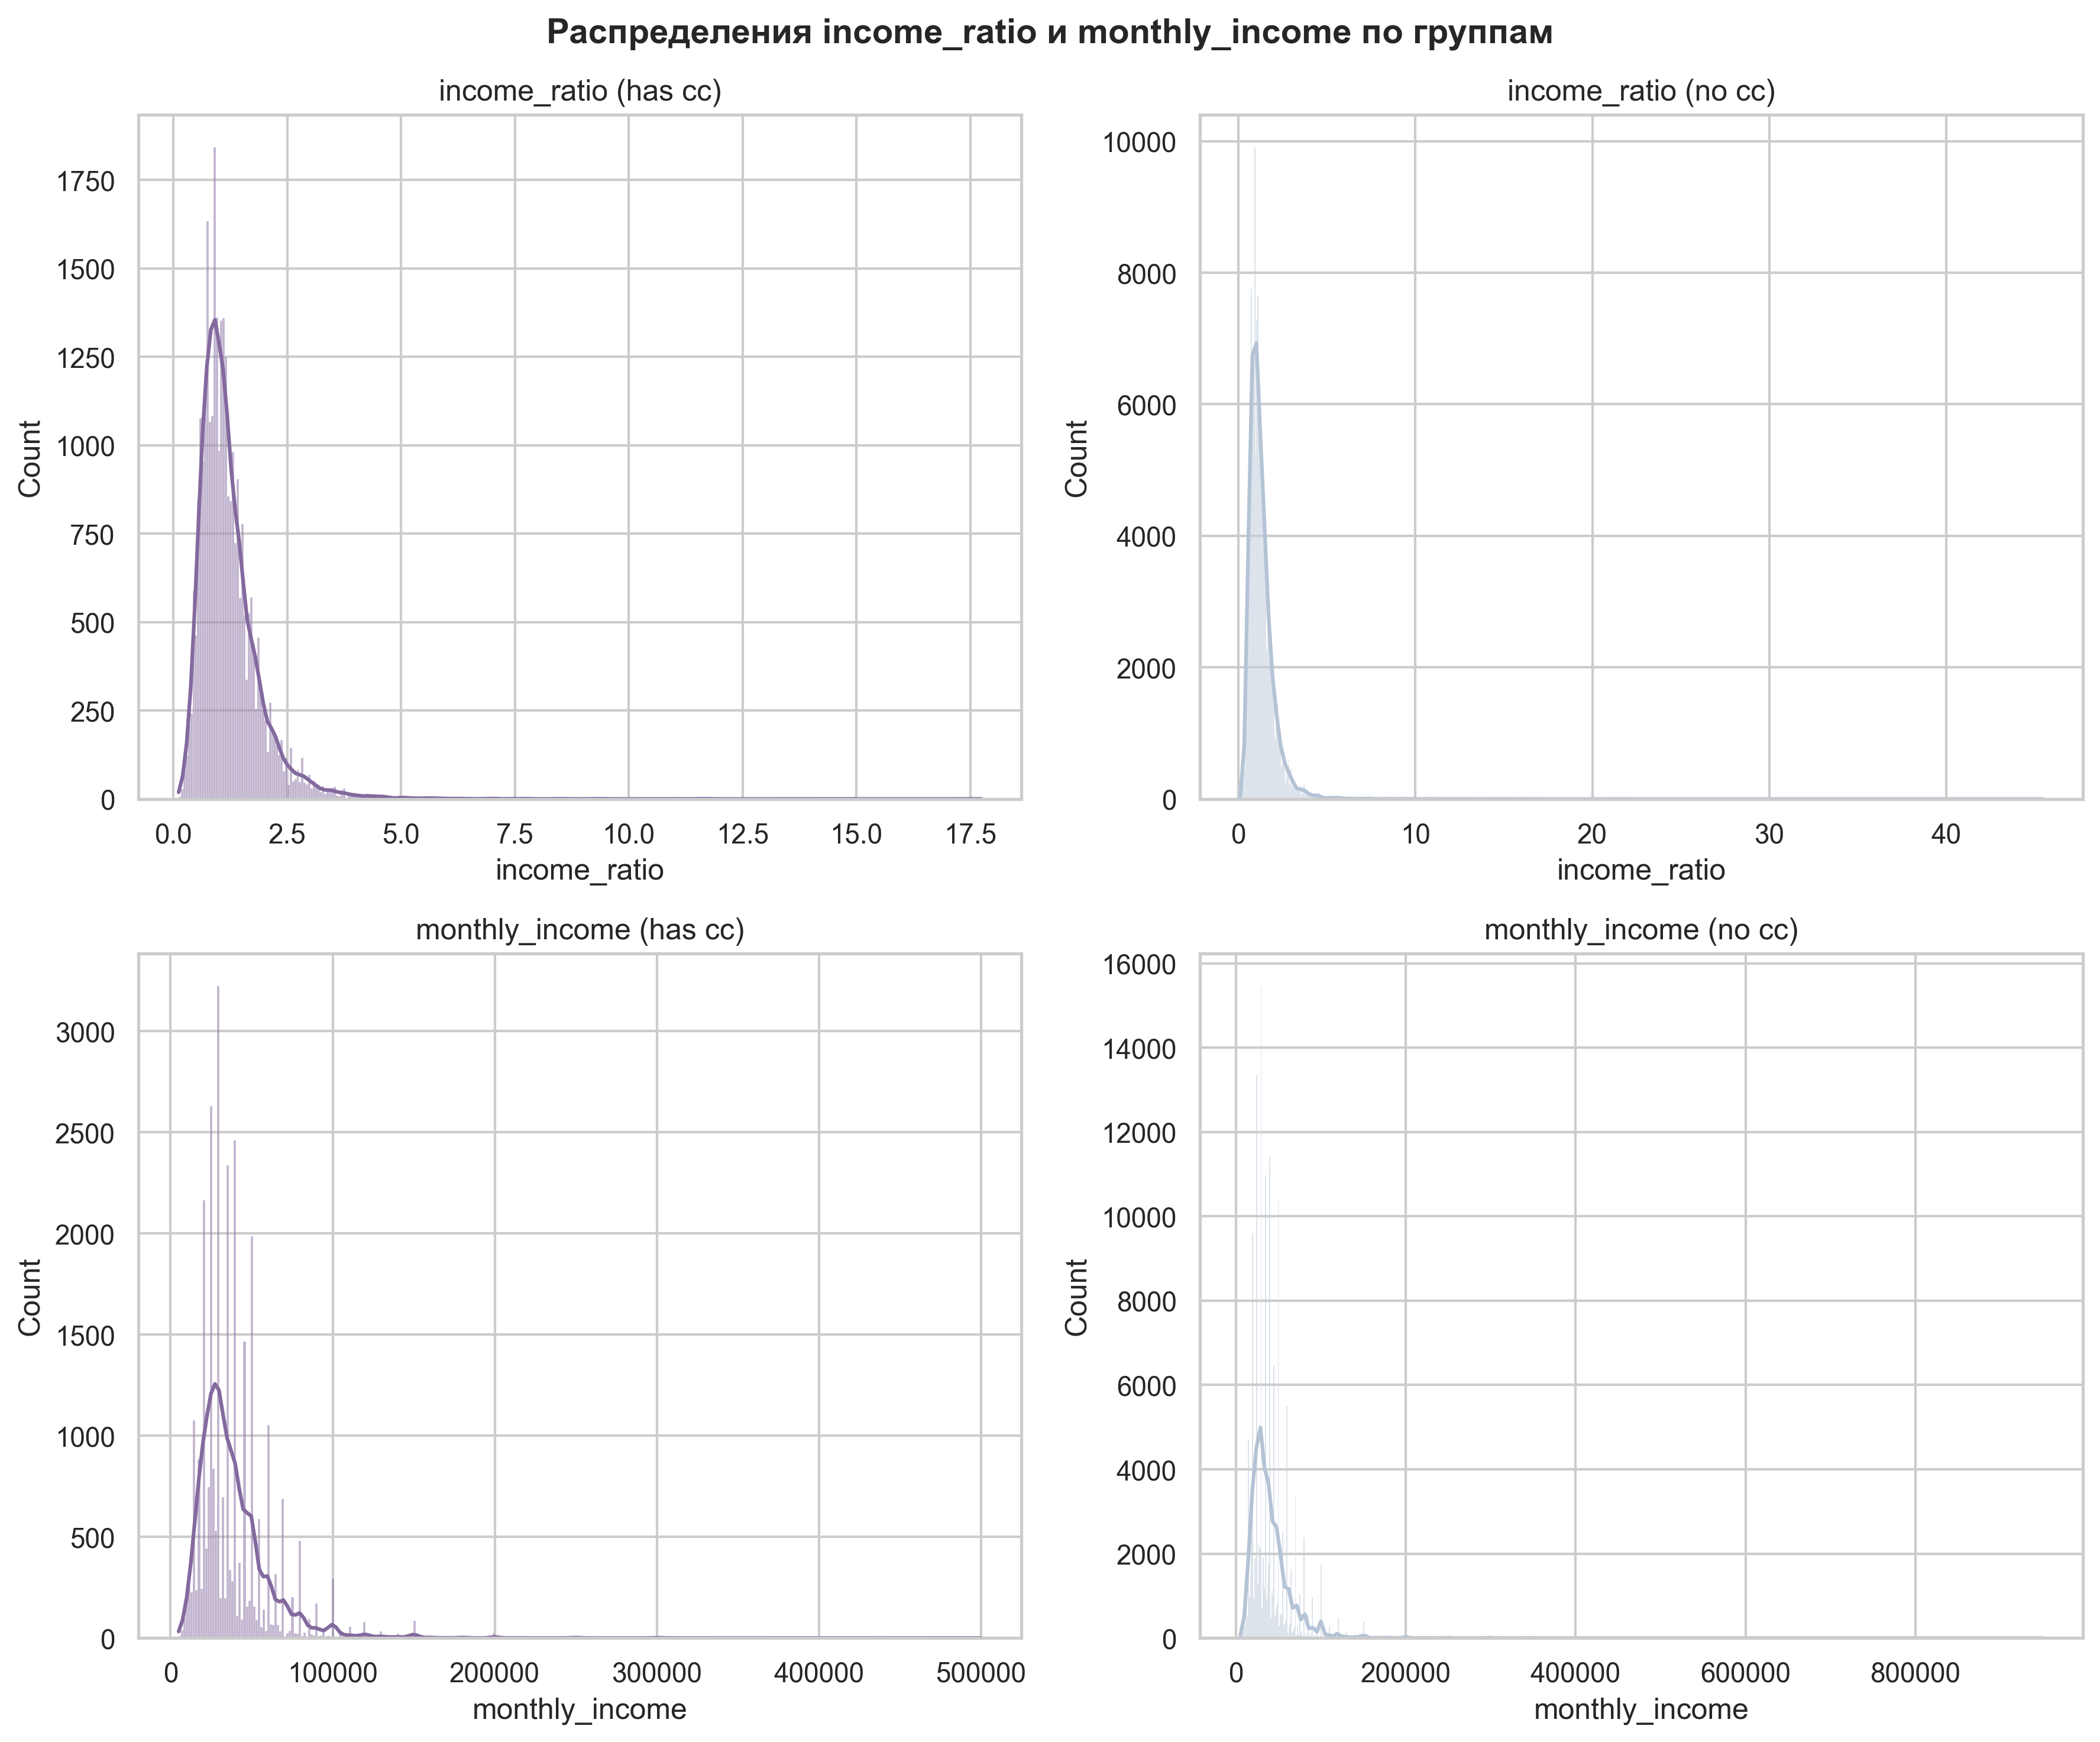

In [164]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), dpi=300)

# income_ratio: has cc
sns.histplot(
    data=data[data["open_account_flg"] == 1],
    x="income_ratio",
    kde=True,
    color="#83699e",
    ax=axes[0, 0],
)
axes[0, 0].set_title("income_ratio (has cc)")

# income_ratio: no cc
sns.histplot(
    data=data[data["open_account_flg"] == 0],
    x="income_ratio",
    kde=True,
    color="#b4c3d5",
    ax=axes[0, 1],
)
axes[0, 1].set_title("income_ratio (no cc)")

# monthly_income: has cc
sns.histplot(
    data=data[data["open_account_flg"] == 1],
    x="monthly_income",
    kde=True,
    color="#83699e",
    ax=axes[1, 0],
)
axes[1, 0].set_title("monthly_income (has cc)")

# monthly_income: no cc
sns.histplot(
    data=data[data["open_account_flg"] == 0],
    x="monthly_income",
    kde=True,
    color="#b4c3d5",
    ax=axes[1, 1],
)
axes[1, 1].set_title("monthly_income (no cc)")

fig.suptitle(
    "Распределения income_ratio и monthly_income по группам", fontsize=14, weight="bold"
)
plt.tight_layout()
plt.show()

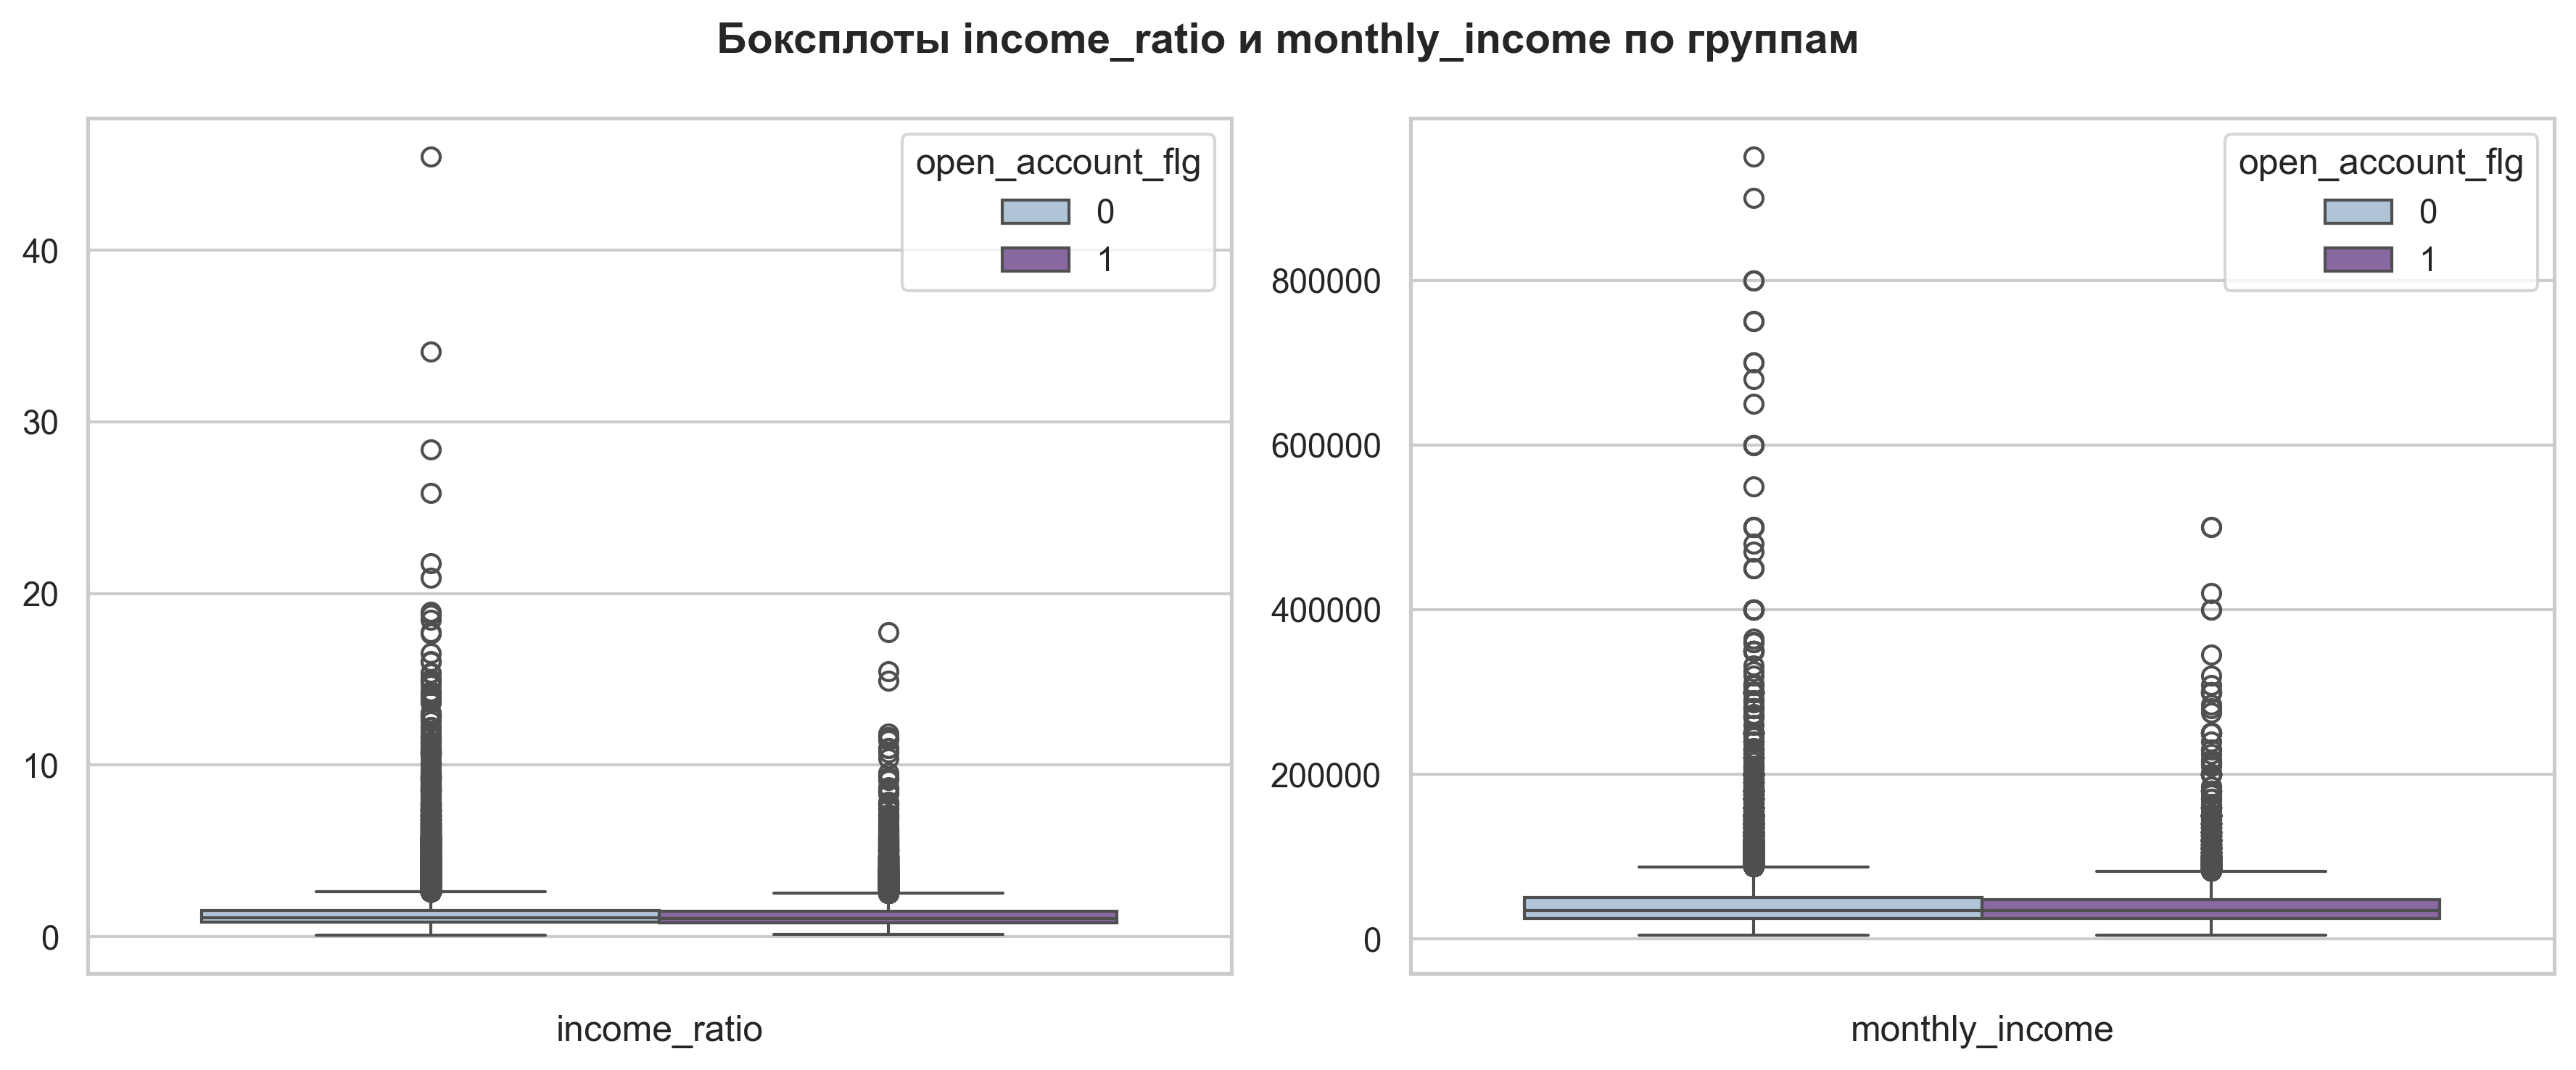

In [165]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), dpi=300)

sns.boxplot(
    data=data, y="income_ratio", hue="open_account_flg", palette="BuPu", ax=axes[0]
)

sns.boxplot(
    data=data, y="monthly_income", hue="open_account_flg", palette="BuPu", ax=axes[1]
)

fig.suptitle(
    "Боксплоты income_ratio и monthly_income по группам", fontsize=14, weight="bold"
)

axes[0].set(ylabel="", xlabel="income_ratio")
axes[1].set(ylabel="", xlabel="monthly_income")

plt.tight_layout()
plt.show()

In [166]:
# Объединение по колонкам
table = pd.concat(
    [stats2.iloc[1:, :2], stats1.iloc[1:, :2]], axis=1, keys=["has cc", "no cc"]
)
table = table.swaplevel(i=0, j=1, axis=1).sort_index(axis=1)

table

income_ratio         monthly_income             
           has cc   no cc         has cc        no cc
mean       1.2333  1.2944    38,855.7363  40,410.9399
std        0.7160  0.7902    23,251.6659  25,406.7711
min        0.1178  0.1047     5,000.0000   5,000.0000
10%        0.5981  0.6282    18,000.0000  20,000.0000
25%        0.7858  0.8315    25,000.0000  25,000.0000
50%        1.0786  1.1177    35,000.0000  35,000.0000
75%        1.4854  1.5408    48,000.0000  50,000.0000
90%        2.0011  2.1277    65,000.0000  70,000.0000
95%        2.4418  2.5660    80,000.0000  80,000.0000
99%        3.7258  3.9447   120,000.0000 121,190.0000
max       17.7384 45.4545   500,000.0000 950,000.0000

##### Анализ распределения абсолютного и относительного доходов
- Распределения обоих признаков в обеих группах ожидаемо сильно скошены вправо. "Тяжелые" правые хвосты обеспечиваются экстремальными значениями (клиенты с очень высокими доходами).
- `monthly_income`: Медианное значение абсолютного дохода в обеих группах равно 35 000 руб. Однако группа клиентов без карт имеет большее число состоятельных клиентов: начиная с 75-го перцентиля они опережают целевую группу по доходам, разница от 2 000 до 5 000 руб. Сверхвысокие доходы (включая максимум в 950 000 руб.) заметно увеличивают средний доход в группе клиентов без карты (40.4k vs 38.86k), поэтому медиана и перцентили лучше характеризуют уровни дохода.
- `income_ratio`: Индекс заработка по всем перцентилям выше у клиентов без карты. Медианный клиент с картой зарабатывает ближе к среднем по региону, чем клиент без карты (1.08 vs 1.12). Боксплоты демонстрируют, что для клиентов без карты диапазон выбросов шире, чем у целевой группы: максимальный индекс равен 45.5 против 17.7 у целевой группы.

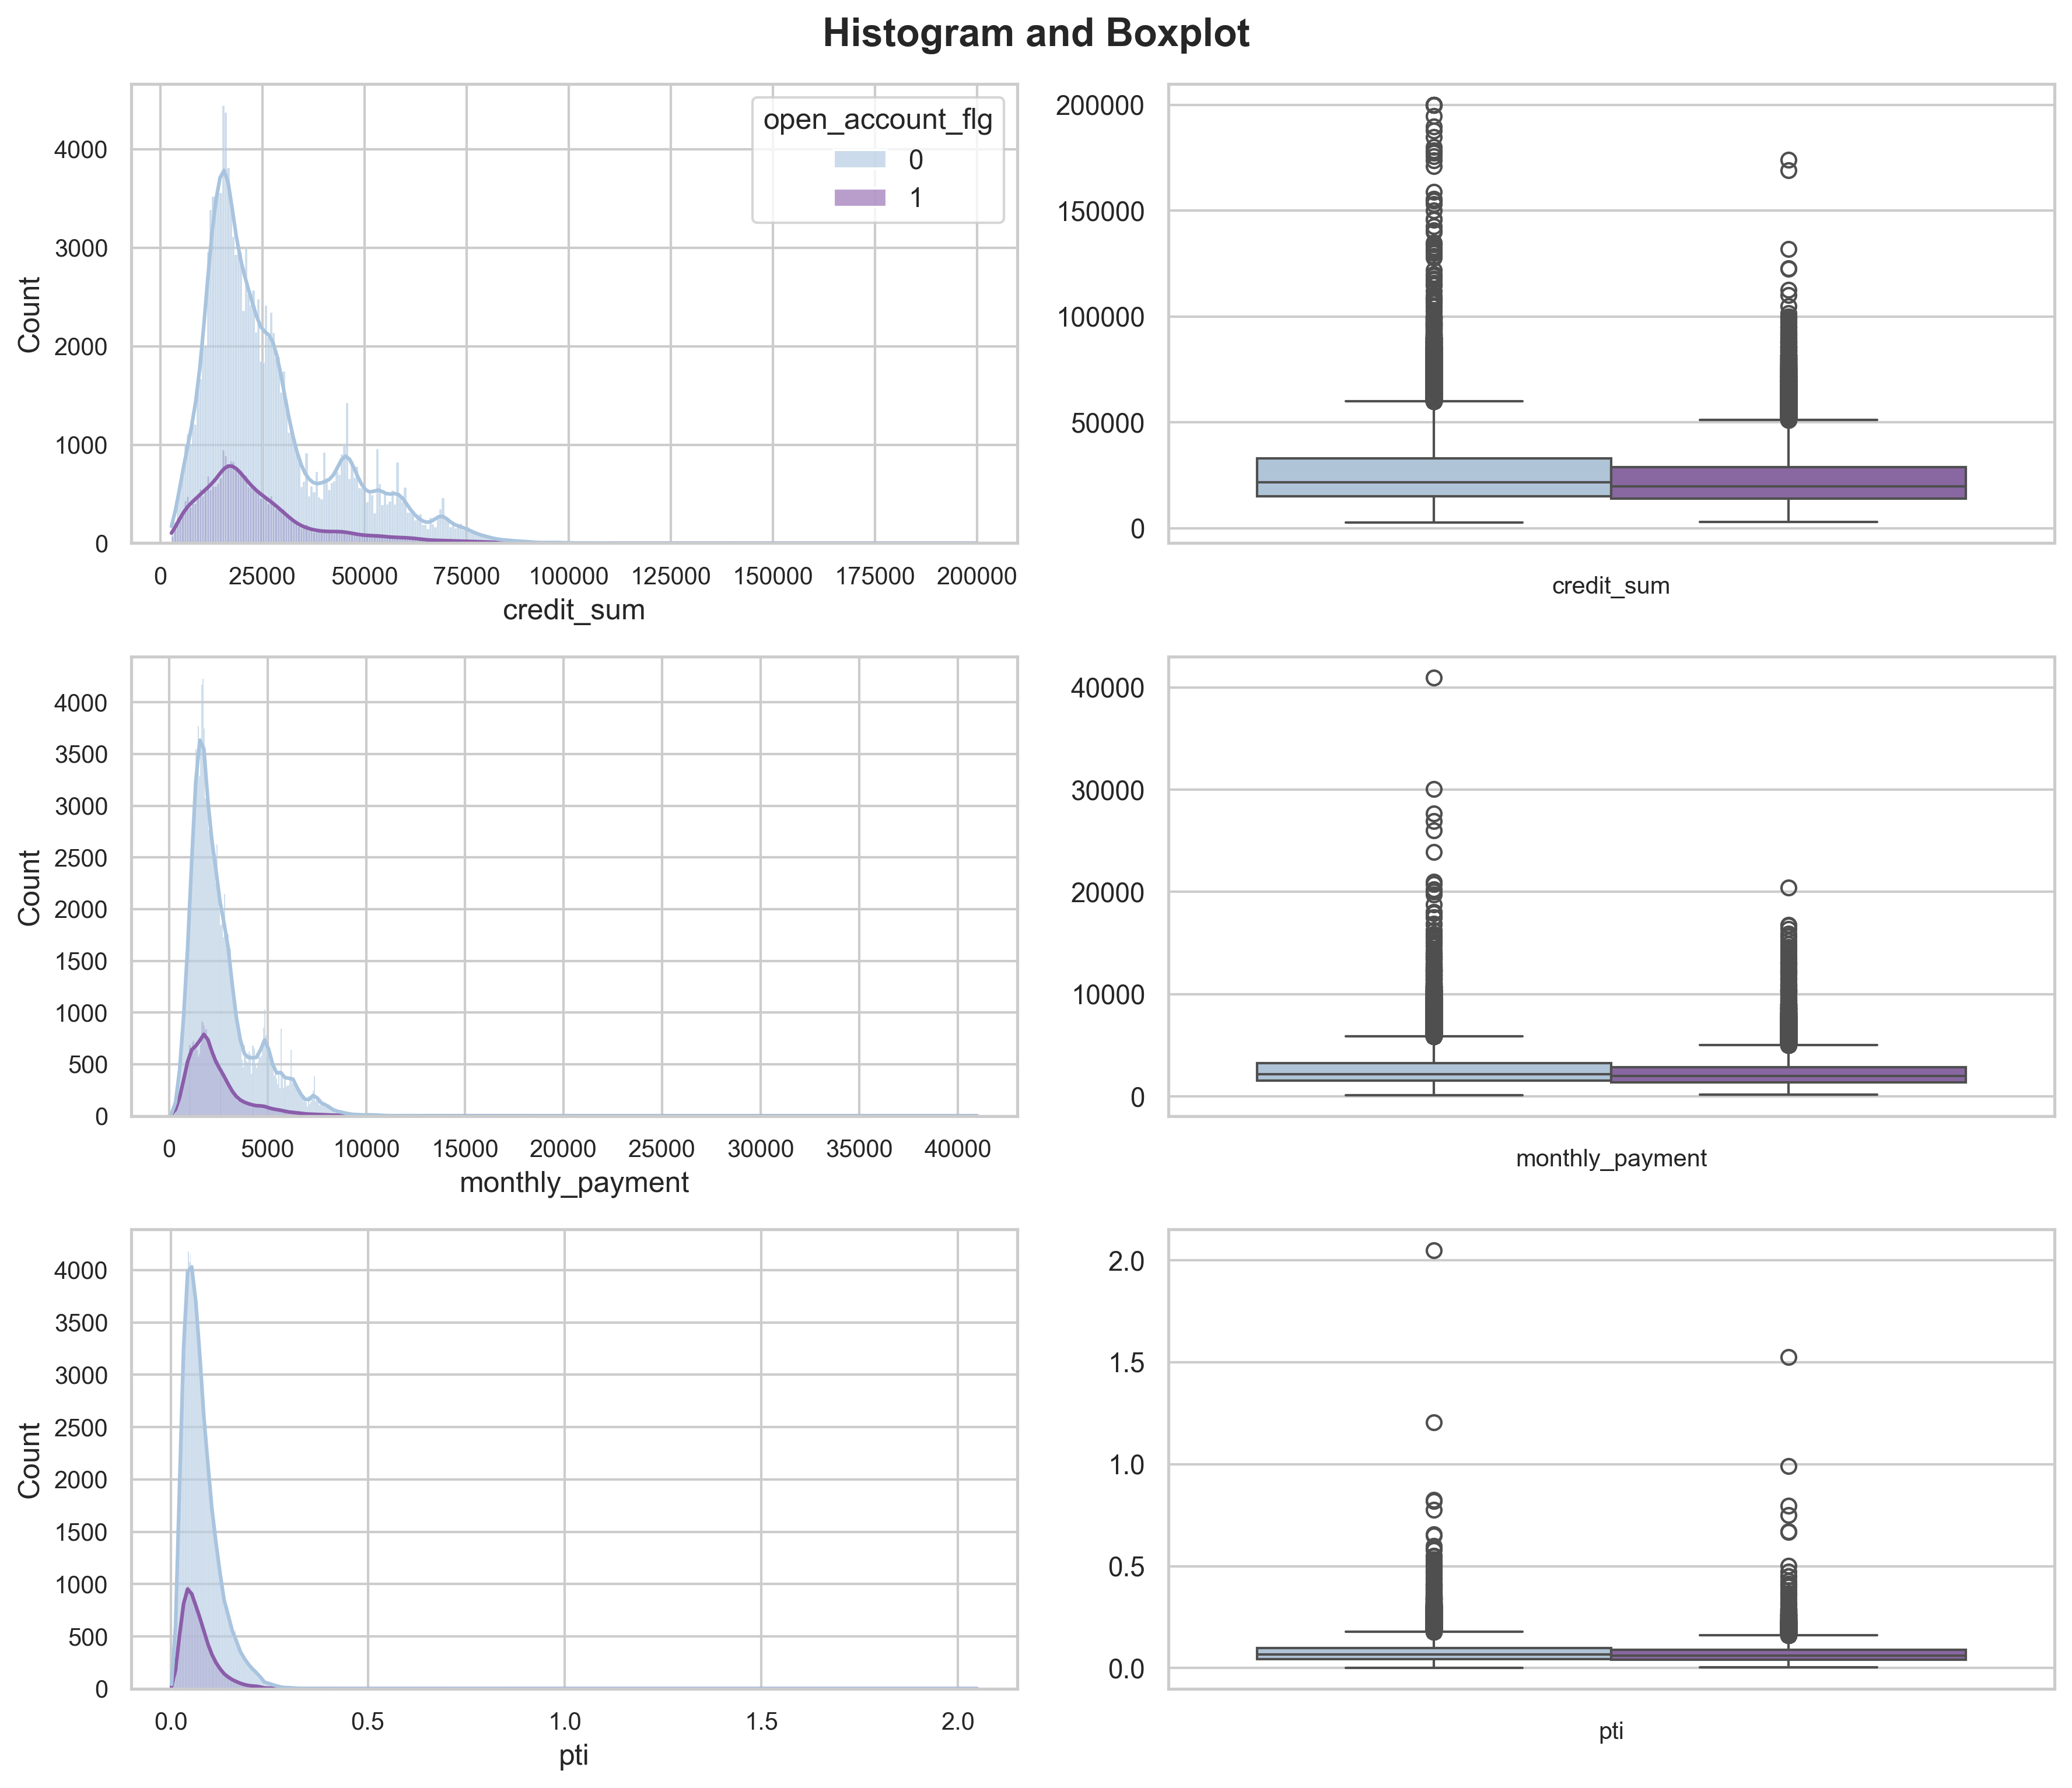

In [167]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), dpi=300)

# 2.1 Распределение признаков
for i, col in enumerate(["credit_sum", "monthly_payment", "pti"]):
    sns.histplot(
        data=data,
        x=col,
        hue="open_account_flg",
        kde=True,
        palette="BuPu",
        ax=axes[i, 0],
        alpha=0.6,
        legend=(i == 0),
    )
    axes[i, 0].set_xlabel(col, fontsize=12)
    axes[i, 0].tick_params(axis="both", labelsize=10)

    sns.boxplot(
        data=data,
        y=col,
        hue="open_account_flg",
        ax=axes[i, 1],
        palette="BuPu",
        legend=False,
    )

    axes[i, 1].set_xlabel(col, fontsize=10)
    axes[i, 1].set_ylabel("")

plt.tight_layout()
fig.suptitle("Histogram and Boxplot", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [168]:
table = pd.concat(
    [stats2.iloc[1:, 2:], stats1.iloc[1:, 2:]], axis=1, keys=["has cc", "no cc"]
)
table = table.swaplevel(i=0, j=1, axis=1).sort_index(axis=1)

table

credit_month           credit_sum              monthly_payment  \
           has cc   no cc       has cc        no cc          has cc   
mean      11.1785 10.9388  23,564.6649  26,634.8877      2,365.2919   
std        4.0700  3.4111  14,880.7840  16,458.2060      1,495.5136   
min        3.0000  3.0000   3,000.0000   2,736.0000        169.7518   
10%        6.0000 10.0000   8,770.0000  11,108.0000        981.1377   
25%       10.0000 10.0000  13,826.7850  15,043.0000      1,384.3273   
50%       10.0000 10.0000  19,789.5000  21,600.0000      1,977.8576   
75%       12.0000 12.0000  28,778.0000  32,990.0000      2,839.0191   
90%       13.0000 12.0000  44,516.8000  51,990.0000      4,331.4964   
95%       19.0000 18.0000  55,341.0000  60,268.9500      5,372.8276   
99%       24.0000 24.0000  73,829.2200  75,579.1900      7,622.7923   
max       36.0000 36.0000 174,000.0000 200,000.0000     20,413.2281   

                    pti         
           no cc has cc  no cc  
mean  2,705.4181 0.0700 0.0768  
std   1,692.6334 0.0438 0.0465  
min     126.1606 0.0030 0.0011  
10%   1,154.3220 0.0273 0.0299  
25%   1,544.0544 0.0402 0.0440  
50%   2,183.1759 0.0604 0.0660  
75%   3,276.9483 0.0886 0.0982  
90%   5,184.8862 0.1243 0.1387  
95%   6,213.5615 0.1513 0.1679  
99%   7,979.0052 0.2131 0.2243  
max  40,969.9706 1.5254 2.0485

In [169]:
data.query("open_account_flg == 0")["credit_month"].value_counts(normalize=True)

table1 = Table(title="credit month TOP-5, has cc", title_style="bold green")
table1.add_column("Количество месяцев", style="cyan")
table1.add_column("Количество", style="cyan")
table1.add_column("Процент", justify="right", style="magenta")

counts = data.query("open_account_flg == 1")["credit_month"].value_counts()
percent = (
    data.query("open_account_flg == 1")["credit_month"].value_counts(normalize=True)
    * 100
)

for item, count in counts[:5].items():
    pct = percent[item]
    table1.add_row(str(item), str(count), f"{pct:.4f}%")

table2 = Table(title="credit month TOP-5, no cc", title_style="bold green")
table2.add_column("Количество месяцев", style="cyan")
table2.add_column("Количество", style="cyan")
table2.add_column("Процент", justify="right", style="magenta")

counts = data.query("open_account_flg == 0")["credit_month"].value_counts()
percent = (
    data.query("open_account_flg == 0")["credit_month"].value_counts(normalize=True)
    * 100
)

for item, count in counts[:5].items():
    pct = percent[item]
    table2.add_row(str(item), str(count), f"{pct:.4f}%")

print(Columns([table1, table2], equal=True))

          credit month TOP-5, has cc                     credit month TOP-5, no cc           
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Количество месяцев ┃ Количество ┃  Процент ┃ ┃ Количество месяцев ┃ Количество ┃  Процент ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 10                 │ 13401      │ 44.5927% │ │ 10                 │ 82193      │ 58.5079% │
│ 12                 │ 9812       │ 32.6501% │ │ 12                 │ 35474      │ 25.2516% │
│ 6                  │ 2355       │  7.8364% │ │ 6                  │ 7835       │  5.5772% │
│ 24                 │ 1339       │  4.4556% │ │ 24                 │ 4738       │  3.3727% │
│ 18                 │ 978        │  3.2544% │ │ 14                 │ 2386       │  1.6984% │
└────────────────────┴────────────┴──────────┘ └────────────────────┴────────────┴──────────┘

##### Анализ кредитных характеристик
- `credit_month`: В обеих группах лидирует срок в 10 месяцев. В группе клиентов без карты доля 10-месячных кредитов составляет 58.51%, что значительно выше, чем среди клиентов с картой (44.59%). Второе и третье места в обеих выборках занимают сроки в 12 и 6 месяцев, причем в обоих случаях доля клиентов целевой группы с таким сроком кредитования выше. Также заметен рост интереса к 24-месячному кредиту: 4.46% против 3.37%.
- `credit_sum`: Заемщики с кредитной картой в среднем берут меньшие суммы, чем клиенты без карт: медианное значение 19 789 руб. против 21 600 руб. На верхних квантилях разрыв увеличивается: например, 90% клиентов из целевой группы берут кредит не выше 44.5 тыс. руб., клиенты без карты - не выше 52 тыс. руб. Боксплоты демонстрируют огромное количество выбросов в обеих группах, максимум достигнул значения в 200 000 руб. в группе клиентов без карты.
- `monthly_payment`: Медианный платеж у заемщиков с кредиткой ниже на 9.4% (1 977 руб. vs 2 183 руб.). Максимальный платеж у клиентов без карты вдвое превосходит максимум для целевой групп: 40 969 против 20 413. Графики распределений демонстрируют скошенную вправо форму, однако для открывших карту распределение сдвинуто влево в зону меньших выплат.
- `pti`: Графики распределений и боксплоты повторяют общую динамику - скошенность вправо и большое количество выбросов. Клиенты целевой группы имеют меньшую долговую нагрузку - медианное значение PTI равно 6.04% против 6.6% у клиентов без карты. Хвост у клиентов без карты выражен сильнее, достигая экстремального значения 2.05 (платеж в два раза выше дохода).

##### Статистическое тестирование
Для подтверждения обнаруженных паттернов (сдвиг в сторону меньших сумм, меньших платежей, меньшей долговой нагрузки и возраста у клиентов с картой) проведем проверку на значимость различий у соответствующих распределений. 

Учитывая выраженную правостороннюю асимметрию и наличие выбросов у всех показателей, для проверки возьмем непараметрический __U-критерий Манна-Уитни__.

Тестирование проводим на ранее созданной подвыборке `data_sample`. Для оценки эффекта для _непрерывных_ признаков используем CLES (Common Language Effect Size / Вероятность превосходства):

$$CLES = P(X_{G_1} > X_{G_2})$$

«Вероятность того, что случайный объект из $G_1$ превзойдёт случайный объект из $G_2$».

Сформулируем гипотезы: 
- __Нулевая гипотеза__ $H_0$: Распределения параметров актуального кредита (`credit_sum`, `monthly_payment`, `pti`) и возраста (`age`) в обеих группах клиентов одинаковы.
- __Альтернативная гипотеза__ $H_1$: Распределения параметров в обеих группах  значимо различаются (существует статистически значимый сдвиг).

In [170]:
import pingouin as pg

for col in ["credit_sum", "monthly_payment", "pti", "age"]:
    group_0 = data_sample.query("open_account_flg == 0")[col]
    group_1 = data_sample.query("open_account_flg == 1")[col]

    stat, p_value = stats.mannwhitneyu(group_0, group_1)

    # Вероятность, что случайное значение первой группы (нет карты)
    # будет БОЛЬШЕ случайного значения второй группы (карта есть)
    cles = pg.compute_effsize(group_0, group_1, eftype="cles")

    console.print(
        f"[bold green]{col}[/bold green]\n"
        f"p-value: {p_value:.4f} (Значимо: {p_value < 0.05})\n"
        f"Размер эффекта (CLES): {cles:.4f}"
    )

credit_sum
p-value: 0.0000 (Значимо: True)
Размер эффекта (CLES): 0.5539

monthly_payment
p-value: 0.0000 (Значимо: True)
Размер эффекта (CLES): 0.5561

pti
p-value: 0.0000 (Значимо: True)
Размер эффекта (CLES): 0.5351

age
p-value: 0.0000 (Значимо: True)
Размер эффекта (CLES): 0.5440

##### Итоги тестирования
Статистическое тестирование подтвердило существование __значимых различий__ между группами по всем рассмотренным признакам.  Направление сдвига подтверждает результаты дескриптивного анализа - у клиентов с картой распределения признаков смещены в сторону _меньших значений_.

Однако на практике сила эффекта _слабая_ - CLES близок к __порогу случайности 0.5.__

__Вывод:__ Наличие кредитной карты статистически связано с более низкими значениями суммы кредита, ежемесячного платежа, долговой нагрузки и возраста. Но небольшая величина эффекта говорит, что эти признаки сами по себе __не являются разделяющими факторами.__

### Исследование кредитной истории и банковского контекста

In [171]:
cols_to_explore = [
    "score_shk",
    "credit_count",
    "overdue_credit_count",
    "is_new",
    "tariff_id"
]

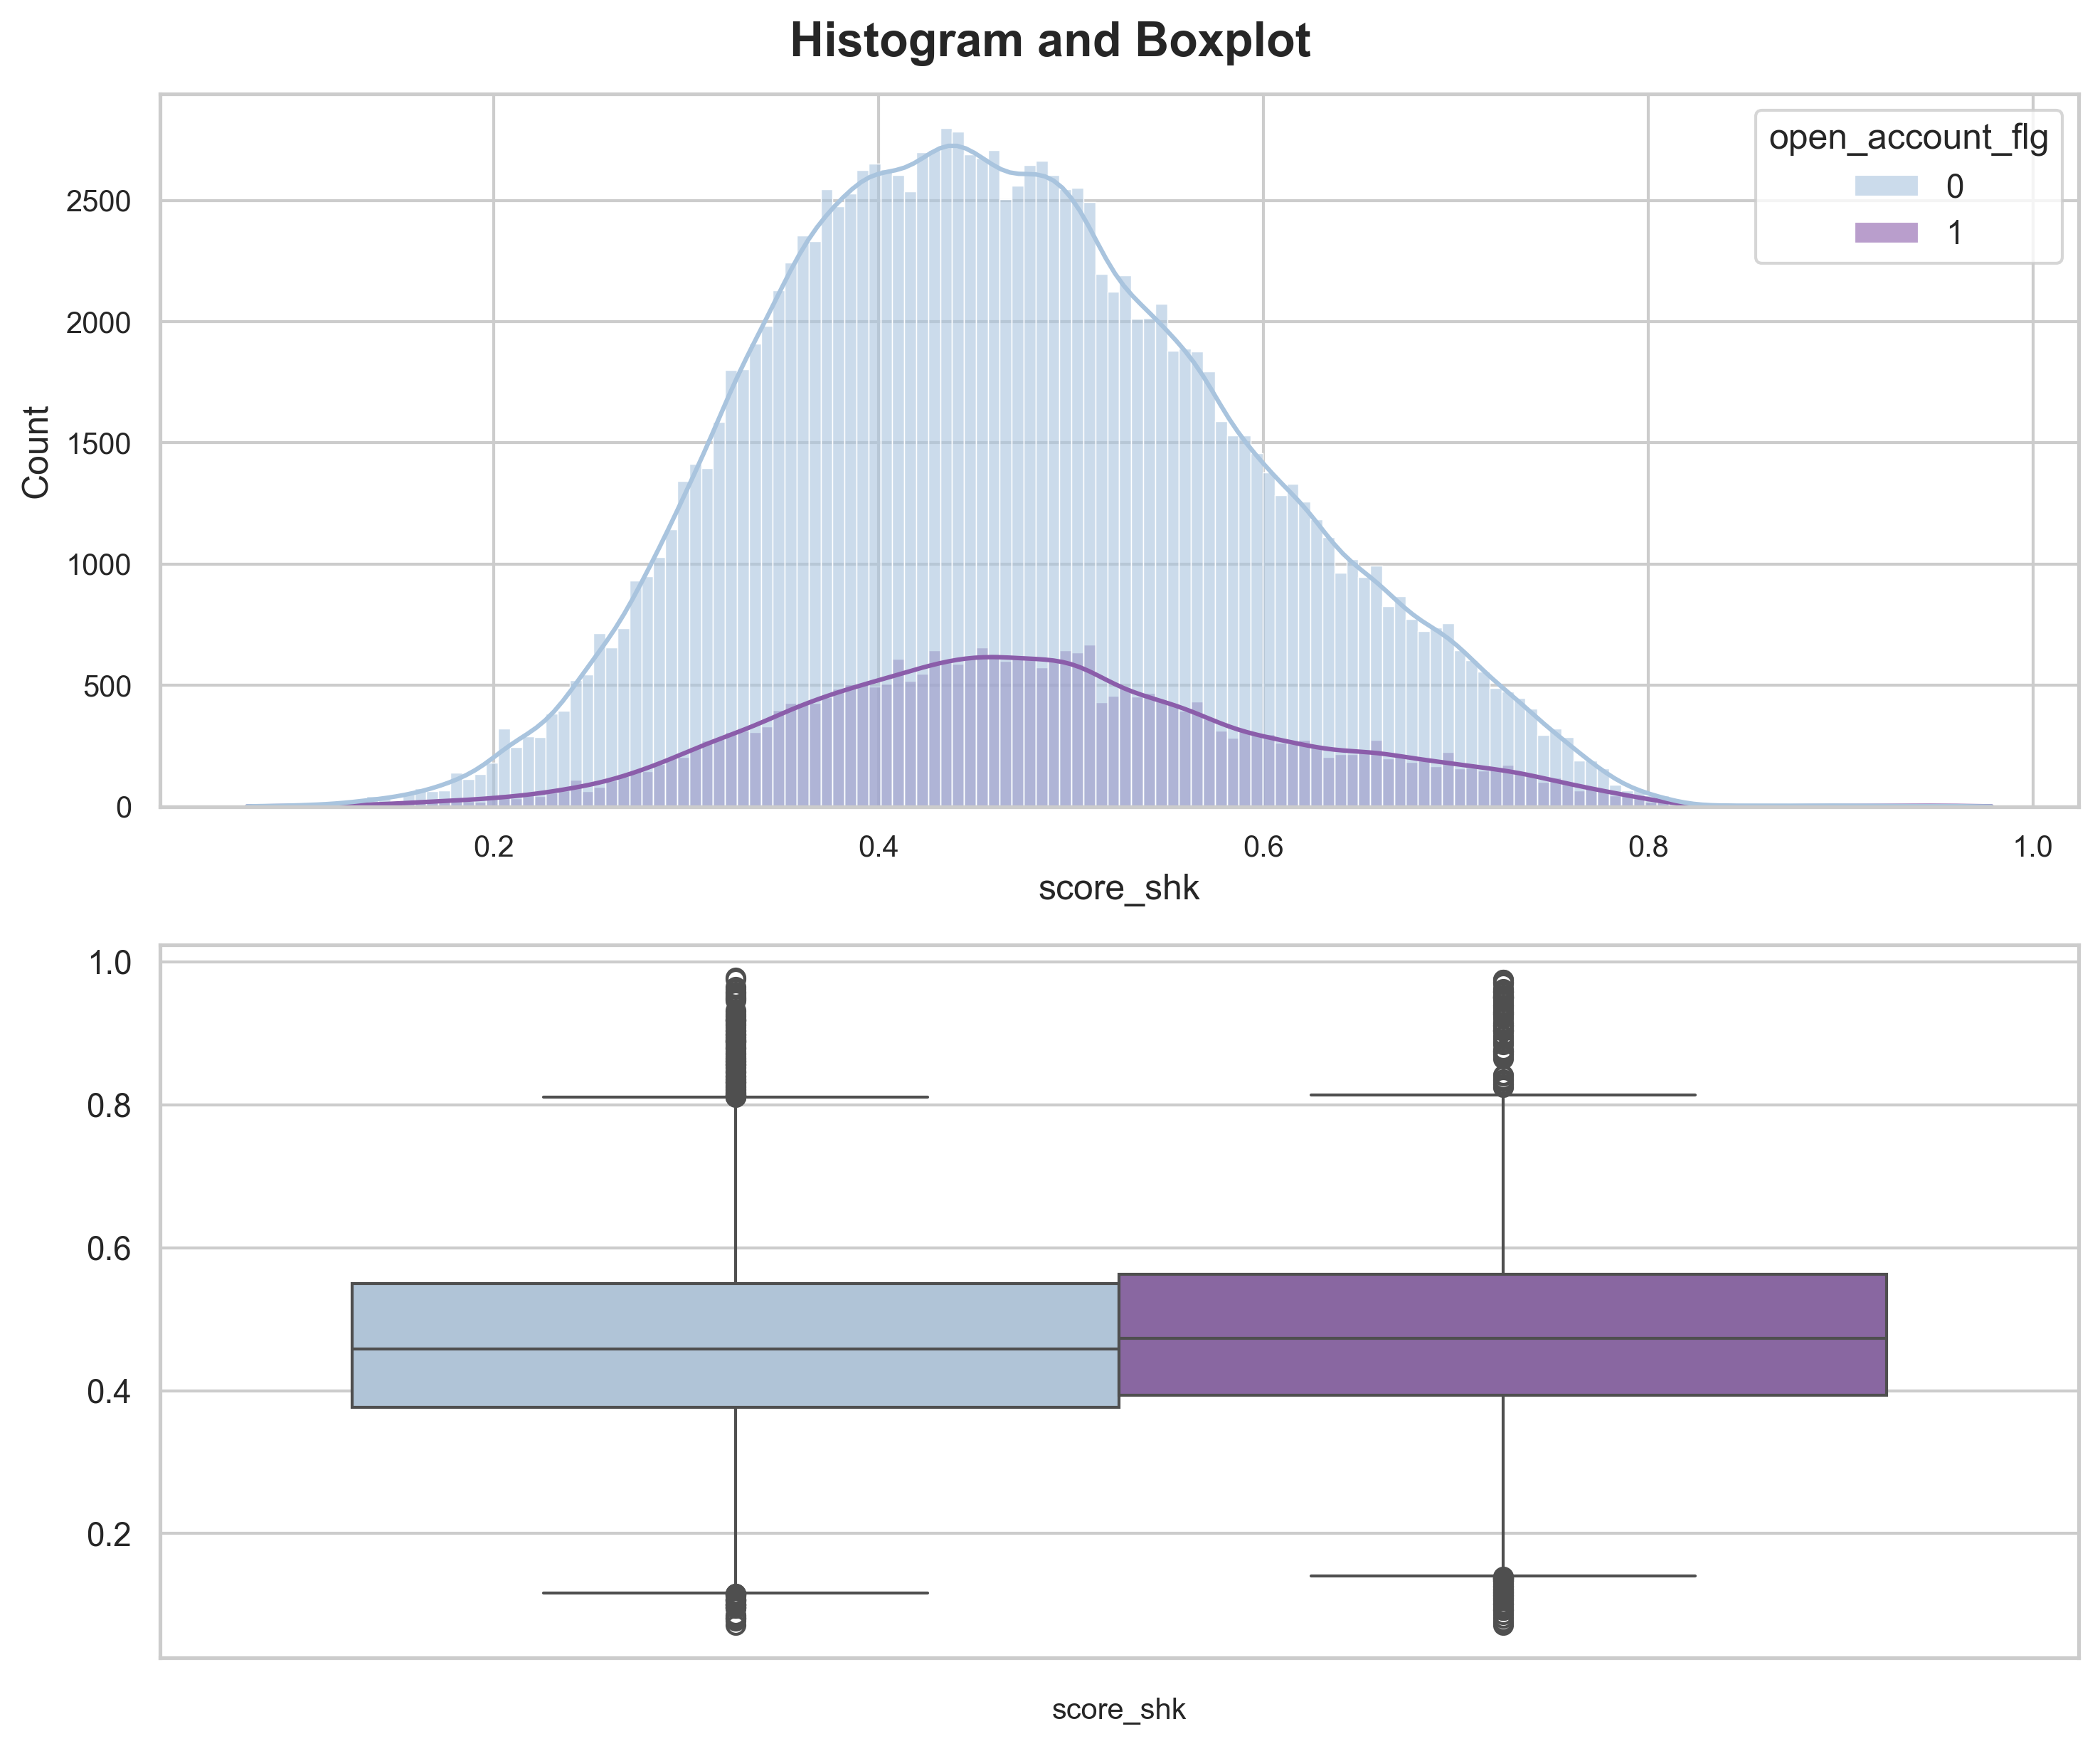

In [172]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), dpi=300)

sns.histplot(
    data=data,
    x="score_shk",
    hue="open_account_flg",
    kde=True,
    palette="BuPu",
    ax=axes[0],
    alpha=0.6,
)
axes[0].set_xlabel("score_shk", fontsize=12)
axes[0].tick_params(axis="both", labelsize=10)

sns.boxplot(
    data=data,
    y="score_shk",
    hue="open_account_flg",
    ax=axes[1],
    palette="BuPu",
    legend=False,
)

axes[1].set_xlabel("score_shk", fontsize=10)
axes[1].set_ylabel("")

plt.tight_layout()
fig.suptitle("Histogram and Boxplot", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [173]:
stats1 = data.query("open_account_flg == 0")[["score_shk"]].describe(percentiles=per)
stats2 = data.query("open_account_flg == 1")[["score_shk"]].describe(percentiles=per)

table = pd.concat([stats2.iloc[1:], stats1.iloc[1:]], axis=1, keys=["has cc", "no cc"])
table = table.swaplevel(i=0, j=1, axis=1).sort_index(axis=1)

table

score_shk       
        has cc  no cc
mean    0.4825 0.4666
std     0.1273 0.1234
min     0.0725 0.0718
10%     0.3260 0.3128
25%     0.3936 0.3765
50%     0.4734 0.4588
75%     0.5626 0.5502
90%     0.6627 0.6373
95%     0.7131 0.6863
99%     0.7751 0.7517
max     0.9754 0.9785

##### Анализ скоринг-балла
- Начиная с 10-го и заканчивая 99-м перцентилем у клиентов с картой распределение скоринг-балла смещено в сторону лучших значений. Этот сдвиг _системный_, не вызванный аномалиями. 
- Среднее значение в группе с картой составляет 0.4825 против 0.466 в группе клиентов без карты, медианное - 0.4734 против 0.4588.
- Оба распределения визуально близки к нормальному, с малой скошенностью вправо в сторону высоких значений балла. На боксплотах  видно огромное количество выбросов в обеих группах в верхней части - клиенты со скорингом выше $\approx$ 0.8 являются единичными исключениями для обеих выборок.

In [174]:
group_0 = data_sample.query("open_account_flg == 0")["score_shk"]
group_1 = data_sample.query("open_account_flg == 1")["score_shk"]

stat, p_value = stats.mannwhitneyu(group_0, group_1)

# Вероятность, что случайное значение первой группы (есть карта)
# будет БОЛЬШЕ случайного значения второй группы (карты нет)
cles = pg.compute_effsize(group_1, group_0, eftype="cles")

console.print(
    f"[bold green]score_shk[/bold green]\n"
    f"p-value: {p_value:.4f} (Значимо: {p_value < 0.05})\n"
    f"Размер эффекта (CLES): {cles:.4f}"
)

score_shk
p-value: 0.0000 (Значимо: True)
Размер эффекта (CLES): 0.5347

Различие в скоринг-баллах статистически значимо: p-value < 0.05 указывает на наличие _закономерности_, а не случайного шума.

Как и ранее, для оценки эффекта рассчитывался показатель CLES. Для показателя скоринга он составил __0.5347__: если случайным образом выбрать по одному клиенту из каждой группы, c вероятностью 53.47% скоринг-балл у клиента с картой будет выше. Это __слабый эффект.__

In [175]:
console.print(
    "Распределение показателей кредитной истории, %",
    style="bold",
    justify="center",
)

tables = []

for col in ["overdue_credit_count", "is_new"]:
    table = Table(title=f"{col}", title_style="bold green")

    table.add_column("Значение", style="cyan")
    table.add_column("has cc, %", justify="right", style="magenta")
    table.add_column("no cc, %", justify="right", style="green")

    grouped_data = (
        data.groupby("open_account_flg")[col]
        .value_counts(normalize=True)
        .reset_index(name="Доля")
    )

    pivot_data = grouped_data.pivot(
        index=col, columns="open_account_flg", values="Доля"
    )

    for value, row in pivot_data.iterrows():
        has_cc_percent = round(row[1] * 100, 2)
        no_cc_percent = round(row[0] * 100, 2)

        table.add_row(str(value), str(has_cc_percent), str(no_cc_percent))

    tables.append(table)

print(Columns(tables, equal=True))

                                  Распределение показателей кредитной истории, %                                   

       overdue_credit_count                       is_new               
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓ ┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Значение ┃ has cc, % ┃ no cc, % ┃ ┃ Значение ┃ has cc, % ┃ no cc, % ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩ ┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ 0.0      │     94.99 │    95.82 │ │ 0        │     88.53 │     95.9 │
│ 1.0      │      4.95 │     4.15 │ │ 1        │     11.47 │      4.1 │
│ 2.0      │      0.05 │     0.02 │ └──────────┴───────────┴──────────┘
│ 3.0      │       0.0 │      0.0 │                                    
└──────────┴───────────┴──────────┘

##### Анализ историй просрочки и новых клиентов
- `overdue_credit_count`: Подавляющее большинство клиентов в обеих группах не имеют просрочек. Однако среди клиентов, открывших карту, доля клиентов с просрочками составляет 5.0%, у клиентов без карты этот показатель равен 4.17%. 
- `is_new`: Среди клиентов, открывших карту, доля новых клиентов составляет 11,47%, против 4,10% среди клиентов без карты. Это может указывать на связь отсутствия кредитной истории с открытием кредитной карты.

Проведем два $\chi^2$-теста для подтверждения статистической взаимосвязи между качеством кредитной истории и склонностью к открытию карты:

In [176]:
data_sample["has_overdue"] = np.where(data_sample["overdue_credit_count"] >= 1, 1, 0)

for col in ["is_new", "has_overdue"]:
    contingency_table = pd.crosstab(data_sample[col], data_sample["open_account_flg"])

    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    cramers_v = stats.contingency.association(contingency_table, method="cramer")

    console.print(
        f"[bold green]{col}[/bold green]\n"
        f"p-value: {p:.4f} (Значимо: {p < 0.05})\n"
        f"Количество степеней свободы: {dof}\n"
        f"V Крамера: {cramers_v:.4f}"
    )

is_new
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.1317

has_overdue
p-value: 0.9674 (Значимо: False)
Количество степеней свободы: 1
V Крамера: 0.0010

##### Интерпретация результатов
- `is_new`: Различие статистически значимо, при этом коэффициент V Крамера равен __0.1317__, что говорит о слабой связи. Однако среди других категориальных признаков (`gender`, `marital_status`, `education`) он _наиболее мощный_. 
- `has_overdue`: Статистически значимых различий _не обнаружено_, близкое к нулю значение V Крамера указывает на полное отсутствие связи с открытием кредитной карты.

In [177]:
for i in [0, 1]:
    credit_counts = data.query("open_account_flg == @i")["credit_count"].value_counts()
    credit_percents = (
        data.query("open_account_flg == @i")["credit_count"].value_counts(
            normalize=True
        )
        * 100
    )

    data1 = credit_counts.iloc[:10]
    data2 = credit_counts.iloc[10:]

    group = "has cc" if i == 1 else "no cc"

    table1 = Table(title=f"credit_count, {group}", title_style="bold green")
    table1.add_column("Кредитов")
    table1.add_column("Клиентов", style="cyan")
    table1.add_column("%", justify="right", style="magenta")

    for item, count in data1.items():
        pct = credit_percents[item]
        table1.add_row(str(item), str(count), f"{pct:.2f}%")

    table2 = Table(title=f"credit_count, {group}", title_style="bold green")
    table2.add_column("Кредитов")
    table2.add_column("Клиентов", style="cyan")
    table2.add_column("%", justify="right", style="magenta")

    for item, count in data2.items():
        pct = credit_percents[item]
        table2.add_row(str(item), str(count), f"{pct:.2f}%")

    print(Columns([table1, table2]))

      credit_count, no cc              credit_count, no cc      
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┓
┃ Кредитов ┃ Клиентов ┃      % ┃ ┃ Кредитов ┃ Клиентов ┃     % ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━┩
│ 1.0      │ 65533    │ 46.65% │ │ 11.0     │ 100      │ 0.07% │
│ 2.0      │ 31121    │ 22.15% │ │ 12.0     │ 53       │ 0.04% │
│ 3.0      │ 19838    │ 14.12% │ │ 13.0     │ 26       │ 0.02% │
│ 4.0      │ 11626    │  8.28% │ │ 14.0     │ 11       │ 0.01% │
│ 5.0      │ 6164     │  4.39% │ │ 15.0     │ 8        │ 0.01% │
│ 6.0      │ 3137     │  2.23% │ │ 17.0     │ 3        │ 0.00% │
│ 7.0      │ 1557     │  1.11% │ │ 19.0     │ 2        │ 0.00% │
│ 8.0      │ 777      │  0.55% │ │ 16.0     │ 1        │ 0.00% │
│ 9.0      │ 367      │  0.26% │ │ 18.0     │ 1        │ 0.00% │
│ 10.0     │ 157      │  0.11% │ └──────────┴──────────┴───────┘
└──────────┴──────────┴────────┘

      credit_count, has cc            credit_count, has cc      
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┓
┃ Кредитов ┃ Клиентов ┃      % ┃ ┃ Кредитов ┃ Клиентов ┃     % ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━┩
│ 1.0      │ 14674    │ 48.83% │ │ 11.0     │ 29       │ 0.10% │
│ 2.0      │ 5831     │ 19.40% │ │ 12.0     │ 21       │ 0.07% │
│ 3.0      │ 4051     │ 13.48% │ │ 13.0     │ 7        │ 0.02% │
│ 4.0      │ 2469     │  8.22% │ │ 15.0     │ 5        │ 0.02% │
│ 5.0      │ 1373     │  4.57% │ │ 14.0     │ 4        │ 0.01% │
│ 6.0      │ 774      │  2.58% │ │ 16.0     │ 3        │ 0.01% │
│ 7.0      │ 404      │  1.34% │ │ 17.0     │ 2        │ 0.01% │
│ 8.0      │ 230      │  0.77% │ │ 19.0     │ 1        │ 0.00% │
│ 9.0      │ 109      │  0.36% │ │ 21.0     │ 1        │ 0.00% │
│ 10.0     │ 63       │  0.21% │ │ 18.0     │ 1        │ 0.00% │
└──────────┴──────────┴────────┘ └──────────┴──────────┴───────┘

In [178]:
df0 = data.query("open_account_flg == 0")["credit_count"].value_counts(normalize=True)
df1 = data.query("open_account_flg == 1")["credit_count"].value_counts(normalize=True)

df = pd.concat([df0, df1], axis=1)
df.columns = ["no cc", "has_cc"]

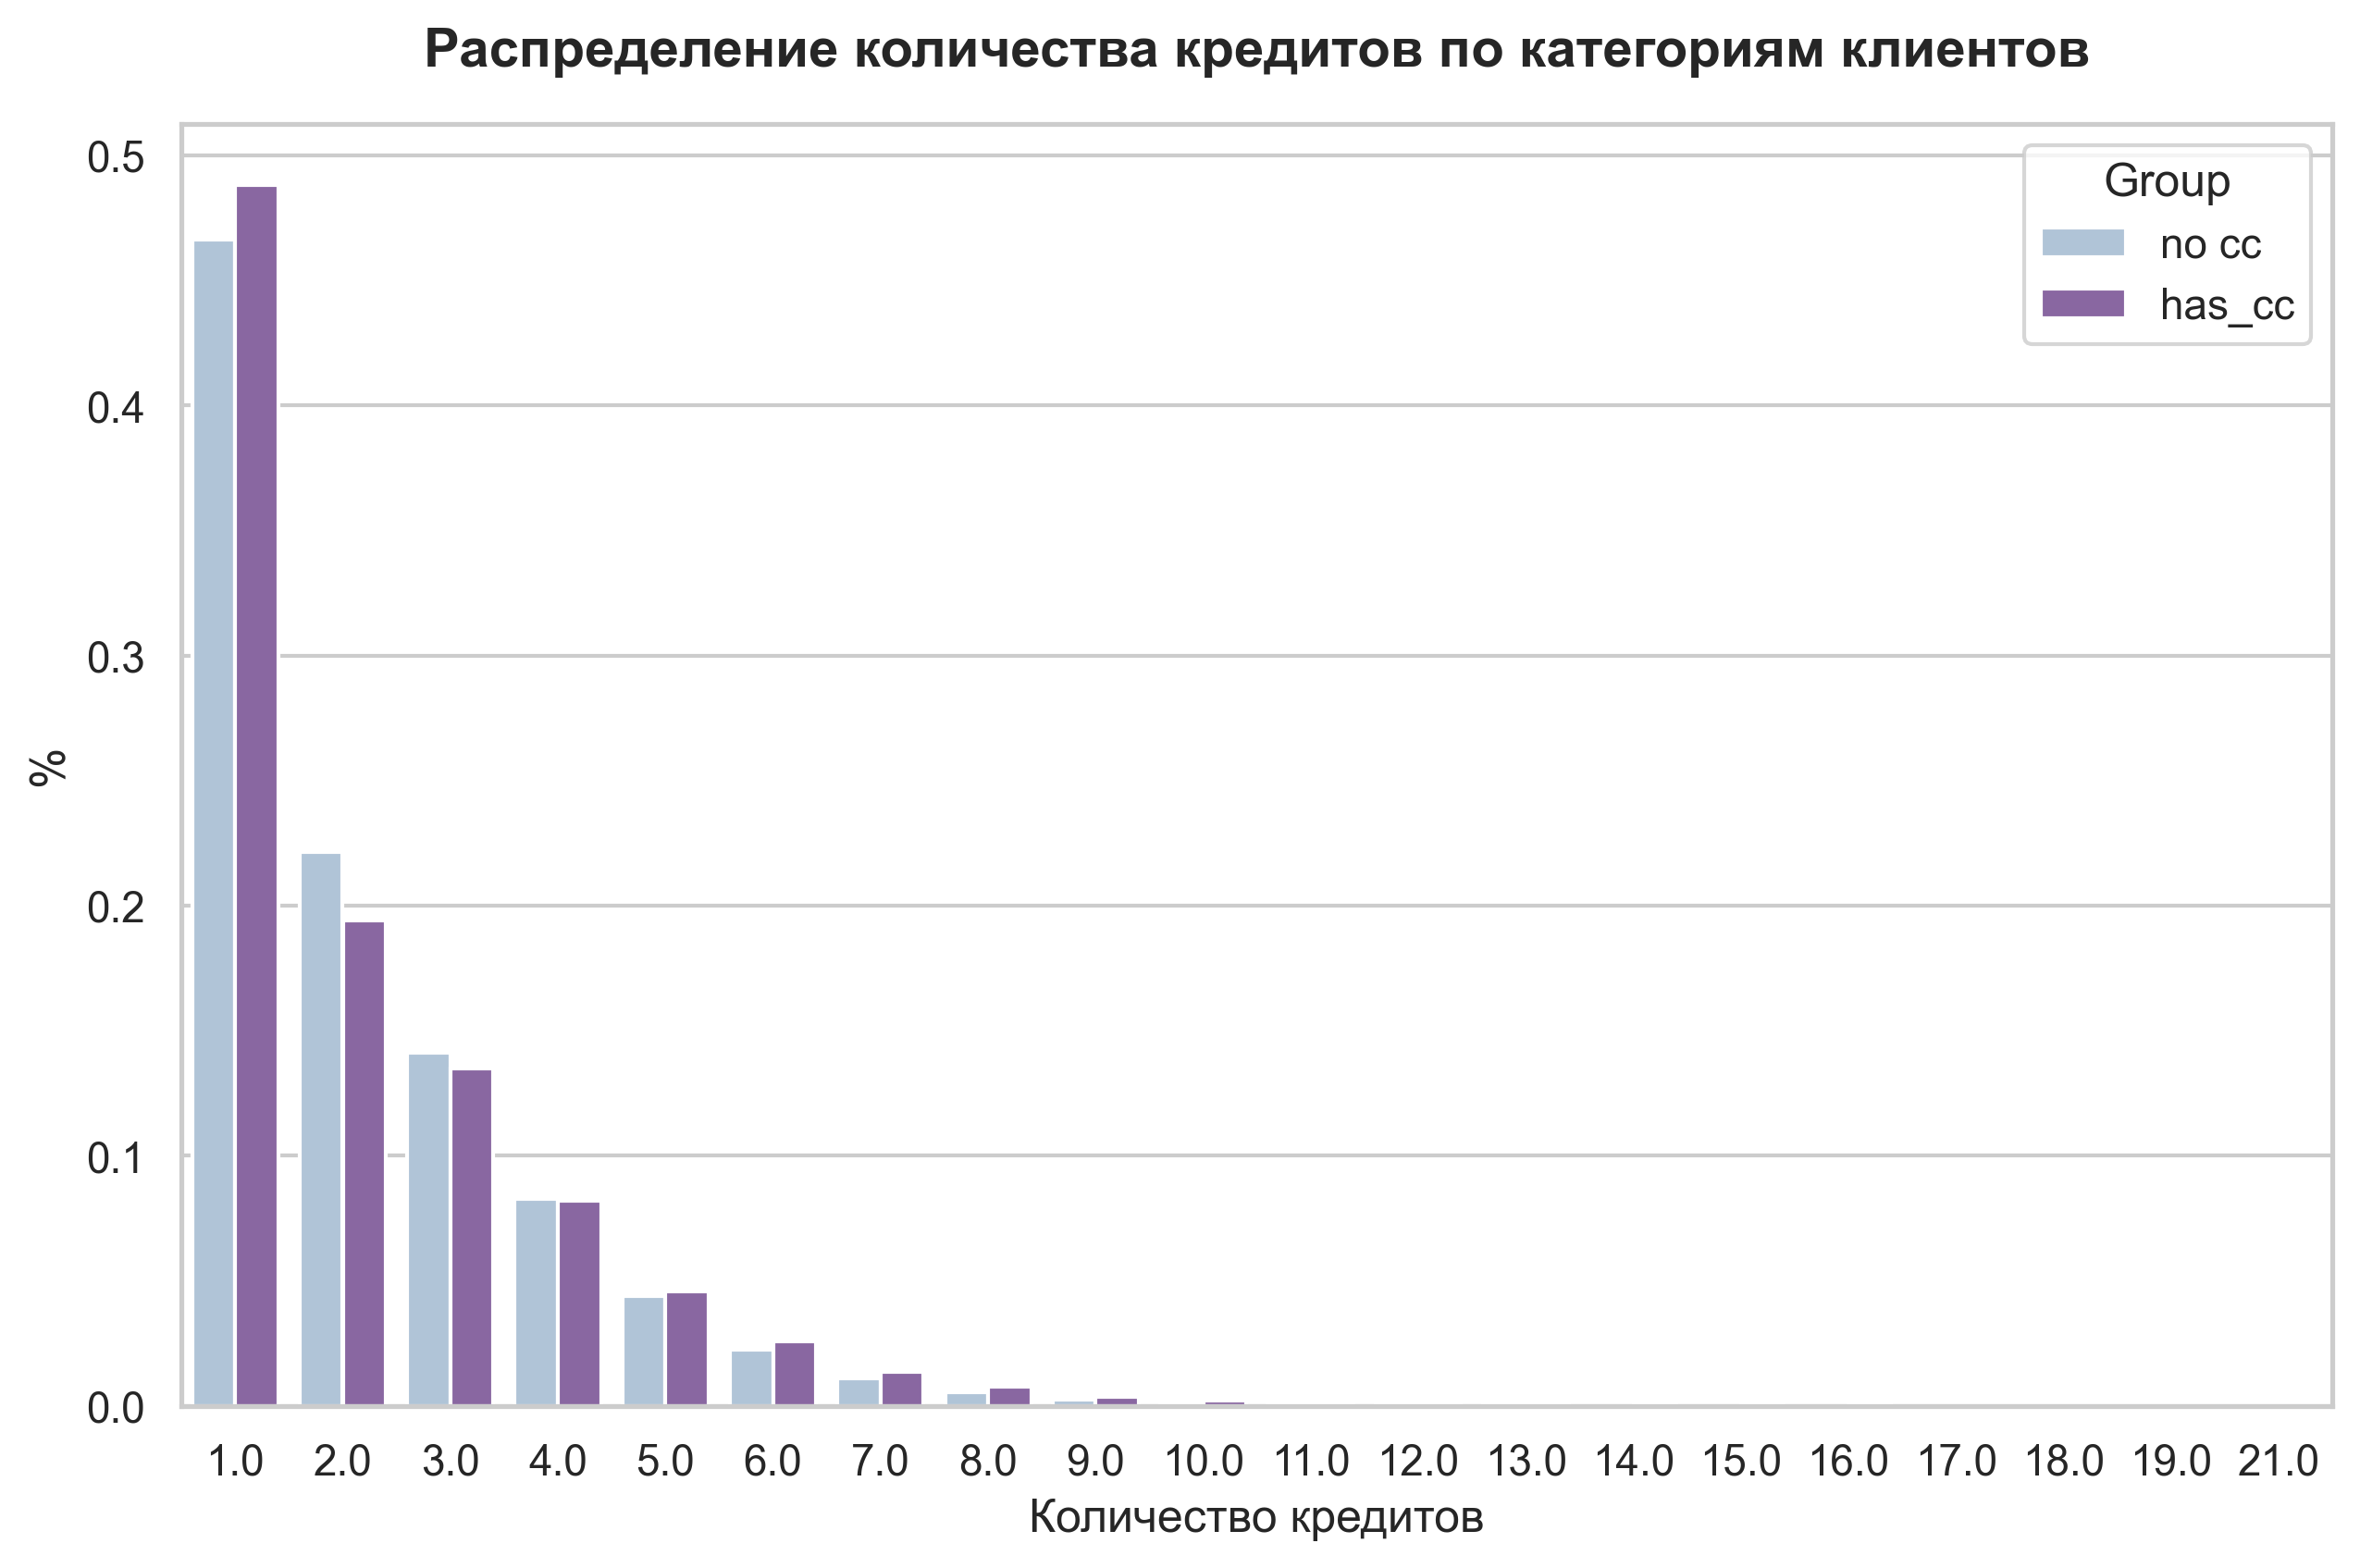

In [179]:
# Растягиваем для барплота
df_melted = df.reset_index().melt(
    id_vars="credit_count", var_name="Group", value_name="Value"
)

plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(data=df_melted, x="credit_count", y="Value", hue="Group", palette="BuPu")

plt.title(
    "Распределение количества кредитов по категориям клиентов",
    fontsize=14,
    pad=15,
    fontweight="bold",
)

plt.xlabel("Количество кредитов", fontsize=12)
plt.ylabel("%", fontsize=12)
plt.show()

##### Анализ распределения количества кредитов
- __Идентичное ядро (1 кредит):__ Самый массовый сегмент. Клиенты, имеющие ровно один активный кредит, составляют 48.83% в группе открывших карту и 46.65% в клиентов без карты. 
- Доля клиентов без карты с 2 и 3 кредитами немного выше: 36.27% против 32.88% у клиентов с картой.
- Зеркальность сегментов с 4 и более кредитами: их доли в группах близки: 18.29% среди открывших карту против 17.08% среди клиентов без карты. 
- В «хвостах» распределения (ультра-заемщики с 11+ кредитами) группа с картами сохраняет лидерство в _долях_ процента.


__Вывод__: Из-за визуального сходства и параллельности распределений показатель количества кредитов не обладает самостоятельной разделяющей способностью для составления портрета. 

In [180]:
table1 = Table(title="tariff_id TOP-10, has cc", title_style="bold green")
table1.add_column("Идентификационный номер", style="cyan")
table1.add_column("Количество", style="cyan")
table1.add_column("Процент", justify="right", style="magenta")

counts = data.query("open_account_flg == 1")["tariff_id"].value_counts()
percent = (
    data.query("open_account_flg == 1")["tariff_id"].value_counts(normalize=True)
    * 100
)

for item, count in counts[:10].items():
    pct = percent[item]
    table1.add_row(str(item), str(count), f"{pct:.2f}%")

table2 = Table(title="tariff_id TOP-10, no cc", title_style="bold green")
table2.add_column("Идентификационный номер", style="cyan")
table2.add_column("Количество", style="cyan")
table2.add_column("Процент", justify="right", style="magenta")

counts = data.query("open_account_flg == 0")["tariff_id"].value_counts()
percent = (
    data.query("open_account_flg == 0")["tariff_id"].value_counts(normalize=True)
    * 100
)

for item, count in counts[:10].items():
    pct = percent[item]
    table2.add_row(str(item), str(count), f"{pct:.2f}%")

print(Columns([table1, table2], equal=True))

             tariff_id TOP-10, has cc                           tariff_id TOP-10, no cc              
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Идентификационный номер ┃ Количество ┃ Процент ┃ ┃ Идентификационный номер ┃ Количество ┃ Процент ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ 2                       │ 13189      │  43.89% │ │ 2                       │ 56069      │  39.91% │
│ 19                      │ 5865       │  19.52% │ │ 28                      │ 33549      │  23.88% │
│ 28                      │ 5514       │  18.35% │ │ 20                      │ 9711       │   6.91% │
│ 20                      │ 1252       │   4.17% │ │ 19                      │ 9649       │   6.87% │
│ 18                      │ 992        │   3.30% │ │ 25                      │ 6768       │   4.82% │
│ 25                      │ 726        │   2.42% │ │ 30                      │ 5169       │   3.68% │
│ 22                      │ 474        │   1.58% │ │ 22                      │ 3444       │   2.45% │
│ 30                      │ 369        │   1.23% │ │ 3                       │ 2882       │   2.05% │
│ 3                       │ 349        │   1.16% │ │ 18                      │ 2346       │   1.67% │
│ 23                      │ 285        │   0.95% │ │ 1                       │ 2085       │   1.48% │
└─────────────────────────┴────────────┴─────────┘ └─────────────────────────┴────────────┴─────────┘

##### Сравнительная таблица

| Тариф | Доля в `has cc` | Доля в `no cc` | Разница (`has cc - no cc`) | Статус тарифа 
| --: | :-- | :-- | :-- | :-- |
| 2 | 43.89% | 39.81% | +3.98% | Самый массовый тариф банка, лидер в обеих группах |
| 19 | 19.52% | 6.87% | +12.65% | Наиболее выраженная связь с открытием карты |
| 28 | 18.35% | 23.88% | -5.53% | Второй по популярности, но имеет перекос в сторону клиентов без карт |
| 20 | 4.17% | 6.91% | -2.74% | Большая доля среди клиентов без карты |
| 18 | 3.3% | 1.67% | +1.63% | Доля выше среди клиентов с картой  |
| 25 | 2.42% | 4.82% | -2.40% | Большая доля среди клиентов без карты | 

__Тарифы - драйверы__:
* Тариф 19 - ключевая точка роста. У клиентов, открывших карту, его доля в 2.84 раза выше, чем в группе клиентов без карты.
* Тариф 2 - базовый и самый массовый. На него приходится 43.89% открытых карт. Он формирует ядро портрета обеих групп из-за масштабности.
* Тариф 18 - умеренный драйвер. Доля в группе клиентов с картой в 2 раза выше (3.3% vs 1.67%). Несмотря на малую долю по сравнению с 19 и 2 тарифами, этот тариф показывает демонстрирует склонность клиентов к оформлению продукта.

__Тарифы - барьеры__:
* Тариф 28 - явная обратная тенденция. Несмотря на то, что он занимает второе место по популярности среди обеих групп, его доля среди клиентов без карты выше (18.35% vs 23.88%). Э
* Тарифы 20 и 25 - смещение в сторону клиентов без карт: суммарная доля составляет 11.73%, когда у клиентов с картой - 6.59% (почти в 1.8 раз меньше).


##### Статистическая проверка значимости Тарифа 19

In [181]:
data_sample["is_tariff_19"] = np.where(data_sample["tariff_id"] == 19, 1, 0)

contingency_table = pd.crosstab(
    data_sample["is_tariff_19"], data_sample["open_account_flg"]
)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
cramers_v = stats.contingency.association(contingency_table, method="cramer")

console.print(
    f"[bold green]is_tariff_19[/bold green]\n"
    f"p-value: {p:.4f} (Значимо: {p < 0.05})\n"
    f"Количество степеней свободы: {dof}\n"
    f"V Крамера: {cramers_v:.4f}"
)

is_tariff_19
p-value: 0.0000 (Значимо: True)
Количество степеней свободы: 1
V Крамера: 0.1500

##### Интерпретация результата
p-value ниже уровня значимости - между тарифом и фактом открытия кредитной карты есть статистически значимая связь. Значение коэффициента V Крамера в __0.150__ указывает на наиболее сильную среди рассмотренных категориальных признаков связь с открытием кредитной карты.

#### Сравнение силы статистической связи непрерывных признаков с открытием кредитной карты

| Признак | $CLES$ | Комментарий |
| --: | :-- | :-- | 
| Ежемесячный платеж | 0.5561 | Лидер среди непрерывных признаков. Клиенты с картами ориентированы на меньшие платежи. |
| Сумма кредита | 0.5539 | Умеренно-слабое влияние. Клиенты с картами кредитуются на меньшие суммы. |
| Возраст  | 0.5440 | Слабое влияние. Владельцы кредитных карт в среднем незначительно моложе. |
| Долговая нагрузка  | 0.5351 | Слабое влияние. У целевой группы нагрузка чуть ниже. |
| Банковский скоринг | 0.5347 | Слабое влияние. У целевой аудитории балл чуть выше. |



__Вопрос практической значимости__

Несмотря на подтвержденную статистическую значимость, показатели CLES для непрерывных признаков находятся близко к 0.5, что указывает на слабые различия между группами. Результат сравнения двух случайных клиентов из разных групп - простое подбрасывание монетки. 

#### Сравнение силы статистической связи категориальных признаков с открытием кредитной карты

| Признак | $V$ | Комментарий |
| --: | :-- | :-- | 
| Тариф 19 | 0.1500 | Главный коммерческий драйвер |
| `is_new`  | 0.1317 | Сильное влияние, главный поведенческий драйвер (формирование кредитной истории) |
| Состоит в браке | 0.0755 | Слабое влияние: клиенты в браке незначительно чаще оформляют кредитки. |
| Должность 10  | 0.0742 | Слабое влияние в целом, но _сильный точечный драйвер_: у целевой группы доля в 2.7 раза выше |
| Высшее образование | 0.0691 | Слабое влияние: клиенты с высшим образованием немного чаще оформляют карты. |
| Пол | 0.0459 | Слабое влияние: гендерный признак почти не разделяет профили |

Поведение клиентов банка в данном датасете определяется не их демографическим профилем (пол, брак, образование), а __конкретным продуктовым предложением__ (Тариф 19) и __финансовой потребностью__ (отсутствие истории в БКИ).

In [182]:
data["is_tariff_19"] = np.where(data["tariff_id"] == 19, 1, 0)

data.query("is_new == 1 and is_tariff_19 == 1")["open_account_flg"].value_counts(
    normalize=True
)

open_account_flg
1   0.6518
0   0.3482
Name: proportion, dtype: float64

### Портрет целевого сегмента

__Наиболее выраженная связь с открытием кредитной карты наблюдается для сочетания двух факторов: отсутствия кредитной истории (`is_new == 1`) и тарифа 19 (`is_tariff_19 == 1`). В данном сегменте доля клиентов с кредитной картой составляет 65.18%.__ 

##### Дополнительно: Профиль клиентов, открывших карту в целевом сегменте

In [199]:
target_clients = data[
    (data["is_new"] == 1)
    & (data["is_tariff_19"] == 1)
    & (data["open_account_flg"] == 1)
]

has_card = data[data["open_account_flg"] == 1]

In [ ]:
cols = [
    "age",
    "monthly_income",
    "credit_sum",
    "monthly_payment",
    "income_ratio",
    "pti",
    "score_shk",
]

series1 = has_card[cols].median()
series2 = target_clients[cols].median()

In [222]:
table = Table(title="Сравнение медианных значений некоторых показателей у клиентов с картой")

table.add_column("Показатель", justify="right", style="cyan", no_wrap=True)
table.add_column("Клиенты с картой", style="magenta")
table.add_column("Целевой сегмент", style="green")
table.add_column("Разница", style="cyan bold")

for feature in series1.index:
    value1 = round(series1[feature], 3)
    value2 = round(series2[feature], 3)
    difference = round(value2 - value1, 3)
    table.add_row(feature, str(value1), str(value2), str(difference))

console.print(table)

 Сравнение медианных значений некоторых показателей у клиентов с  
                              картой                              
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃      Показатель ┃ Клиенты с картой ┃ Целевой сегмент ┃ Разница ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│             age │ 33.0             │ 24.0            │ -9.0    │
│  monthly_income │ 35000.0          │ 30000.0         │ -5000.0 │
│      credit_sum │ 19789.5          │ 23283.0         │ 3493.5  │
│ monthly_payment │ 1977.858         │ 2491.353        │ 513.495 │
│    income_ratio │ 1.079            │ 0.976           │ -0.103  │
│             pti │ 0.06             │ 0.082           │ 0.022   │
│       score_shk │ 0.473            │ 0.45            │ -0.023  │
└─────────────────┴──────────────────┴─────────────────┴─────────┘

Целевой сегмент отличается от клиентов, открывших карту в целом, более молодым возрастом: медианный возраст составляет __24 года__ против 33 лет. При этом медианный доход ниже (30 000 против 35 000 руб.), а медианные значения суммы кредита (23 283 руб. против 19 790 руб.) и ежемесячного платежа выше (2 491 руб. против 1978 руб.). Долговая нагрузка также выше: медианное значение PTI составляет __8.2%__ против __6.0%__.